# proj2_dataset - 자동차 도장 품질 검사 데이터셋

## 프로젝트 개요
자동차 제조 공정의 도장 품질 검사(AI 비전 검사) 데이터셋. 검사 기록, 결함 상세, 마스터 테이블, 이미지+YOLO 라벨로 구성.

---

## 디렉토리 구조

```
proj2_dataset/
├── track_a_data/              # 정형 데이터 (CSV 10개)
│   ├── inspection_master.csv      312 MB   3,000,000행
│   ├── daily_summary.csv           31 MB     318,812행
│   ├── defect_detail.csv           23 MB     170,904행
│   ├── defect_summary.csv          10 KB         120행
│   ├── master_color.csv           379 B          15행
│   ├── master_defect_type.csv     318 B          10행
│   ├── master_plant_line.csv      308 B          13행
│   ├── master_model.csv           283 B          12행
│   ├── master_zone.csv            244 B          12행
│   └── master_camera.csv          165 B           6행
│
├── track_a_images/            # 이미지 + 라벨 데이터
│   ├── images/
│   │   ├── train/                  47 MB   800장 (.jpg)
│   │   └── val/                    12 MB   200장 (.jpg)
│   └── labels/                    YOLO 형식 (.txt)
│       ├── train/                 2.6 MB   800개
│       └── val/                   656 KB   200개
│
└── CLAUDE.md                  # (이 파일)
```

---

## CSV 파일 상세

### 1. inspection_master.csv (312 MB, 3,000,000행)
> 개별 검사 건 전체 기록

| 컬럼 | 설명 |
|---|---|
| inspection_id | 검사 고유 ID (INS로 시작) |
| body_number | 차체 번호 |
| model_code | 모델 코드 (→ master_model) |
| color_code | 색상 코드 (→ master_color) |
| plant_code, line_code | 공장/라인 (→ master_plant_line) |
| camera_id | 카메라 ID (→ master_camera) |
| operator_id | 작업자 ID |
| shift | 교대조 (A/B/C) |
| inspection_datetime | 검사 일시 |
| inference_time_sec | AI 추론 시간 |
| result | 검사 결과 (PASS/FAIL) |
| confidence_score | 신뢰도 |
| takt_time_sec | 택트 타임 |
| ambient_temp_c | 주변 온도 |
| humidity_pct | 습도 |

**샘플 데이터:**
```
INS0000085621,SV7-085621,SV7,B3L,ULN,UL5,CAM01,OP0081,A,2023-01-01 06:00:01,1.269,FAIL,0.9156,2.65,23.8,33.8
INS0000746064,MQ4-746064,MQ4,WC9,ULN,UL5,CAM05,OP0032,A,2023-01-01 06:00:03,1.27,PASS,0.8849,2.83,18.2,50.6
INS0002631543,GV70-2631543,GV70,P2W,ASN,AS3,CAM02,OP0086,A,2023-01-01 06:00:45,1.228,PASS,0.8989,2.91,23.4,37.2
INS0000535451,EV9-535451,EV9,ABP,ULN,UL2,CAM06,OP0063,A,2023-01-01 06:00:49,1.034,PASS,0.9799,2.68,16.9,55.1
INS0001435264,NE1-1435264,NE1,P2W,ULN,UL3,CAM01,OP0054,A,2023-01-01 06:00:55,1.21,PASS,0.9039,2.45,23.7,58.4
```

---

### 2. daily_summary.csv (31 MB, 318,812행)
> 일별/공장/라인/모델/교대조 집계

**헤더:** date, plant_code, line_code, model_code, shift, total_inspections, pass_count, avg_inference_time, avg_takt_time, avg_confidence, avg_temp, avg_humidity, fail_count, yield_rate

**샘플 데이터:**
```
2023-01-01,ASN,AS1,CK,A,11,11,1.265,2.905,0.932,22.53,43.75,0,100.0
2023-01-01,ASN,AS1,CK,B,20,19,1.209,2.722,0.912,23.06,43.83,1,95.0
2023-01-01,ASN,AS1,CN7,A,19,19,1.145,2.802,0.916,22.92,45.67,0,100.0
2023-01-01,ASN,AS1,CN7,B,20,20,1.218,2.864,0.931,23.22,44.59,0,100.0
2023-01-01,ASN,AS1,CN7,C,2,2,1.249,2.73,0.914,22.9,51.8,0,100.0
```

---

### 3. defect_detail.csv (23 MB, 170,904행)
> 개별 결함 상세 정보

**헤더:** defect_id, inspection_id, body_number, defect_type_code, defect_type_name, severity, zone_code, zone_name, x_position_mm, y_position_mm, width_mm, height_mm, area_mm2, confidence, rework_required, estimated_rework_min, detection_datetime

**샘플 데이터:**
```
DEF0000000001,INS0000085621,SV7-085621,DNT,덴트,MAJOR,BUMPER_F,프론트범퍼,1314.9,68.8,15.2,7.5,369.55,0.9447,Y,45,2023-01-01 06:00:01
DEF0000000002,INS0001402028,LX2-1402028,GAP,Gap불량,CRITICAL,BUMPER_F,프론트범퍼,1795.1,115.2,22.3,1.9,113.23,0.9207,Y,60,2023-01-01 06:01:46
DEF0000000003,INS0002162718,CV-2162718,PDR,도장흘림,MINOR,ROOF,루프,150.4,199.1,33.2,16.8,114.12,0.9325,N,25,2023-01-01 06:05:15
DEF0000000004,INS0002162718,CV-2162718,ORG,오렌지필,MINOR,BUMPER_R,리어범퍼,1637.9,54.9,40.7,21.2,173.42,0.8718,N,20,2023-01-01 06:05:15
DEF0000000005,INS0002532927,CV-2532927,PDR,도장흘림,MINOR,TRUNK,트렁크,1918.7,302.4,6.5,3.8,424.51,0.9345,N,25,2023-01-01 06:05:50
```

---

### 4. defect_summary.csv (10 KB, 120행)
> 결함유형 × 구역 × 심각도별 집계

**헤더:** defect_type_code, defect_type_name, zone_code, zone_name, severity, defect_count, avg_area_mm2, avg_confidence, total_rework_min

**샘플 데이터:**
```
CLP,클립마크,BUMPER_F,프론트범퍼,MINOR,728,252.09,0.921,10920
CLP,클립마크,BUMPER_R,리어범퍼,MINOR,713,259.76,0.920,10695
CLP,클립마크,FD,프론트도어,MINOR,686,259.31,0.918,10290
CLP,클립마크,FF,프론트펜더,MINOR,709,252.64,0.920,10635
CLP,클립마크,HOOD,후드,MINOR,710,254.00,0.920,10650
```

---

### 5. master_color.csv (379 B, 15행)
> 색상 코드 마스터

**헤더:** color_code, color_name

**전체 데이터 (15행):** P2W(퓨어화이트), YW6(문라이트클라우드), B3L(아비스블랙), R4M(플레임레드), SWP(스노우화이트펄) 등

---

### 6. master_defect_type.csv (318 B, 10행)
> 결함 유형 마스터

**헤더:** defect_type_code, defect_type_name, severity, std_rework_time_min

**샘플:** SCR(스크래치/MINOR/15분), DNT(덴트/MAJOR/45분), PBB(도장기포/MINOR/30분), PDR(도장흘림/MINOR/25분), GAP(Gap불량/CRITICAL/60분)

---

### 7. master_plant_line.csv (308 B, 13행)
> 공장-라인 마스터

**헤더:** plant_code, plant_name, line_code

**공장:** ULN(울산공장) - UL1～UL5, ASN(아산공장) - AS1～AS3, GWJ(광주공장) - GW1～GW2, HWS(화성공장) - HW1～HW3

---

### 8. master_model.csv (283 B, 12행)
> 차량 모델 마스터

**헤더:** model_code, model_name, brand, default_line

**샘플:** SS3(쏘나타/HMC), SV7(싼타페/HMC), NQ5(투싼/HMC), CN7(아반떼/HMC), LX2(팰리세이드/HMC)

---

### 9. master_zone.csv (244 B, 12행)
> 검사 구역 마스터

**헤더:** zone_code, zone_name

**구역:** HOOD(후드), FF(프론트펜더), FD(프론트도어), RD(리어도어), RF(리어펜더), TRUNK(트렁크), BUMPER_F/R, ROOF, ROCKER, QTR_L/R

---

### 10. master_camera.csv (165 B, 6행)
> 카메라 마스터

**헤더:** camera_id, position, station_id

**전체:** CAM01(좌측면/INS-001), CAM02(우측면/INS-001), CAM03(상부/INS-002), CAM04(전면/INS-002), CAM05(후면/INS-003), CAM06(하부/INS-003)

---

## 이미지/라벨 데이터

- **이미지:** JPG, 파일명 패턴 `{zone}_{color}_{id}.jpg` (예: `roof_black_000391.jpg`)
- **라벨:** YOLO 형식 TXT (`class_id cx cy w h`), 정규화 좌표
- **Train/Val 비율:** 800:200 (80:20)
- 일부 라벨 파일은 비어있음 (결함 없는 이미지)

## 테이블 관계 (FK)
```
inspection_master ─┬─ model_code    → master_model
                   ├─ color_code    → master_color
                   ├─ plant_code + line_code → master_plant_line
                   └─ camera_id     → master_camera

defect_detail ─────┬─ inspection_id → inspection_master
                   ├─ defect_type_code → master_defect_type
                   └─ zone_code     → master_zone

daily_summary ─────┬─ plant_code + line_code → master_plant_line
                   └─ model_code    → master_model

defect_summary ────┬─ defect_type_code → master_defect_type
                   └─ zone_code     → master_zone
```

---

## 1단계 EDA 결과 (2026-04-05)

### 데이터 품질 요약

| 항목 | inspection_master | defect_detail | daily_summary |
|---|---|---|---|
| 행 수 | 3,000,000 | 170,904 | 318,812 |
| 컬럼 수 | 16 | 17 | 14 |
| **Null 비율** | **0% (전 컬럼)** | **0% (전 컬럼)** | **0% (전 컬럼)** |
| 날짜 범위 | 2023-01-01 ～ 2025-01-24 | 2023-01-01 ～ 2025-01-24 | 2023-01-01 ～ 2025-01-24 |
| 고유 일수 | — | — | 755일 |

> **Null 값 없음** — 3개 테이블 모두 결측치가 전혀 없는 완전한 데이터셋.

---

### PASS/FAIL 비율 (inspection_master)

| result | 건수 | 비율 |
|---|---|---|
| PASS | 2,877,908 | 95.93% |
| FAIL | 122,092 | **4.07%** |

---

### 수치형 기술통계

#### inspection_master

| 지표 | inference_time_sec | confidence_score | takt_time_sec | ambient_temp_c | humidity_pct |
|---|---|---|---|---|---|
| mean | 1.200 | 0.920 | 2.800 | 23.00 | 45.00 |
| std | 0.150 | 0.040 | 0.300 | 3.00 | 8.00 |
| min | 0.800 | 0.850 | 1.320 | 7.70 | 2.00 |
| max | 1.963 | 0.990 | 4.300 | 37.60 | 84.90 |

#### defect_detail

| 지표 | x_position_mm | y_position_mm | width_mm | height_mm | area_mm2 | confidence | est_rework_min |
|---|---|---|---|---|---|---|---|
| mean | 1,050.7 | 425.6 | 26.0 | 15.5 | 252.5 | 0.920 | 32.0 |
| std | 548.2 | 216.1 | 13.8 | 8.4 | 142.8 | 0.041 | 24.7 |
| min | 100.0 | 50.0 | 2.0 | 1.0 | 5.0 | 0.850 | 10 |
| max | 2,000.0 | 800.0 | 50.0 | 30.0 | 500.0 | 0.990 | 120 |

#### daily_summary

| 지표 | total_inspections | pass_count | fail_count | yield_rate |
|---|---|---|---|---|
| mean | 9.41 | 9.03 | 0.38 | 95.50 |
| std | 7.27 | 7.02 | 0.67 | 11.59 |
| min | 1 | 0 | 0 | 0.00 |
| max | 45 | 44 | 7 | 100.00 |
| median | 8 | 8 | 0 | 100.00 |

---

### 결함 분포

#### 결함 유형 (defect_detail)
| 코드 | 건수 | 비율 |
|---|---|---|
| SCR (스크래치) | 42,432 | 24.8% |
| DNT (덴트) | 25,583 | 15.0% |
| PBB (도장기포) | 20,738 | 12.1% |
| DST (이물질) | 17,150 | 10.0% |
| PDR (도장흘림) | 17,111 | 10.0% |
| ORG (오렌지필) | 13,782 | 8.1% |
| GAP (Gap불량) | 13,605 | 8.0% |
| CLP (클립마크) | 8,492 | 5.0% |
| CRK (크랙) | 6,841 | 4.0% |
| WLD (용접불량) | 5,170 | 3.0% |

#### 심각도 (defect_detail)
| severity | 건수 | 비율 |
|---|---|---|
| MINOR | 119,705 | 70.0% |
| CRITICAL | 25,616 | 15.0% |
| MAJOR | 25,583 | 15.0% |

#### 구역별 분포: 12개 zone에 거의 균등 분포 (14,085～14,464건, 편차 < 3%)

---

### FK 정합성 체크 결과

| FK 관계 | 결과 |
|---|---|
| inspection_master.model_code → master_model | **OK** |
| inspection_master.color_code → master_color | **OK** |
| inspection_master.plant_code+line_code → master_plant_line | **OK** |
| inspection_master.camera_id → master_camera | **OK** |
| defect_detail.inspection_id → inspection_master | **OK** (0건 불일치) |
| defect_detail.defect_type_code → master_defect_type | **OK** |
| defect_detail.zone_code → master_zone | **OK** |
| daily_summary.model_code → master_model | **OK** |
| daily_summary.plant_code+line_code → master_plant_line | **OK** |

> **FK 정합성 100%** — 모든 외래키 관계가 마스터 테이블과 정확히 매칭됨.

### Cross-check: daily_summary.total_inspections 합계 = 3,000,000 = inspection_master 행 수 → **일치**

---

### 주요 발견사항

1. **데이터 품질 우수** — Null 0%, FK 정합성 100%, 집계 cross-check 일치.
2. **FAIL률 4.07%** — 전체 300만건 중 122,092건 불량. 불균형 분류 문제(imbalanced).
3. **FAIL 1건당 평균 결함 1.4개** — 170,904 결함 / 122,092 FAIL. 1결함 70%, 2결함 20%, 3결함 10%.
4. **스크래치(SCR)가 최다 결함** — 전체의 24.8%. 다음으로 덴트(15%), 도장기포(12.1%).
5. **심각도 MINOR 70%** — CRITICAL(GAP/CRK/WLD) 15%, MAJOR(DNT) 15%.
6. **구역별 균등 분포** — 12개 zone에 거의 동일하게 분포 (시뮬레이션 데이터 특성).
7. **수치형 분포 대칭적** — mean ≈ median, 정규분포에 가까운 패턴.

---

## 2단계 심층 EDA 결과 (2026-04-05)

> 분석 노트북: `eda_visualization.ipynb` (14개 시각화 섹션, 실행 검증 완료)

### 핵심 발견사항 (Top 3)

| # | 발견 | 수치 | 비즈니스 임팩트 |
|---|---|---|---|
| 1 | **C조(야간 22시) 불량률 돌출** | 6.02% (A조 4.12%, B조 3.77%) | C조는 전체의 5.9%만 담당하나 불량률이 평균 대비 +48%. 야간 품질 감독 강화 필요 |
| 2 | **교대 시작 직후 불량 급증** | 06시 6.08%, 07시 5.94%, 21시 5.95% vs 정상시간 3.4～3.6% | 설비 워밍업/인수인계 공백. 교대 직후 30분 집중 모니터링 권장 |
| 3 | **저습도(< 25%) 환경에서 불량률 상승** | 4.3～4.5% vs 평균 4.07% | 도장 부스 습도 모니터링 알림 시스템 도입 권장. 온도는 영향 없음 |

### 교대조·시간대 상세

- **A조(06～13시)**: 4.12%, 검사 1,411,316건 (47.0%)
- **B조(14～21시)**: 3.77%, 검사 1,412,017건 (47.1%) — 가장 우수
- **C조(22시)**: 6.02%, 검사 176,667건 (5.9%) — 25개월간 일관되게 높음 (구조적 패턴)
- 월별 불량률 3.97～4.20% 범위에서 안정적 — 계절 트렌드 없음, 공정 in-control 상태

### 결함 유형별 재작업 비용 (노트북 실행 확인)

| 결함 | 심각도 | 건수 | 비율 | 총 재작업(h) | 재작업률 |
|---|---|---|---|---|---|
| SCR (스크래치) | MINOR | 42,432 | 24.8% | 10,608 | 30% |
| DNT (덴트) | MAJOR | 25,583 | 15.0% | **19,187** | 100% |
| PBB (도장기포) | MINOR | 20,738 | 12.1% | 10,369 | 30% |
| DST (이물질) | MINOR | 17,150 | 10.0% | 2,858 | 30% |
| PDR (도장흘림) | MINOR | 17,111 | 10.0% | 7,130 | 30% |
| ORG (오렌지필) | MINOR | 13,782 | 8.1% | 4,594 | 31% |
| GAP (Gap불량) | CRITICAL | 13,605 | 8.0% | **13,605** | 100% |
| CLP (클립마크) | MINOR | 8,492 | 5.0% | 2,123 | 30% |
| CRK (크랙) | CRITICAL | 6,841 | 4.0% | 10,262 | 100% |
| WLD (용접불량) | CRITICAL | 5,170 | 3.0% | 10,340 | 100% |
| **합계** | | **170,904** | | **91,076** | |

### 결함 관리 우선순위

| 순위 | 결함 | 근거 |
|---|---|---|
| 1순위 | DNT(덴트) | 재작업 비용 최대 (19,187h), 100% 재작업 필수, 고빈도(15%) |
| 2순위 | GAP(Gap불량) | 재작업 비용 2위 (13,605h), CRITICAL, 100% 재작업 |
| 3순위 | WLD(용접불량), CRK(크랙) | 건당 120분/90분으로 단건 비용 극대 (총 10,340h/10,262h) |
| 4순위 | SCR(스크래치) | 발생 빈도 1위(24.8%), 다중결함의 핵심 동반자 (Top 10 동시발생 조합 중 7개에 포함) |

### 결함 동시발생 Top 5

| 조합 | 건수 |
|---|---|
| DNT(덴트) + SCR(스크래치) | 4,002 |
| PBB(도장기포) + SCR(스크래치) | 3,288 |
| DST(이물질) + SCR(스크래치) | 2,699 |
| PDR(도장흘림) + SCR(스크래치) | 2,642 |
| GAP(Gap불량) + SCR(스크래치) | 2,181 |

> 다중결함 검사 36,609건 중 SCR이 거의 모든 조합에 동반 — SCR 예방이 다중결함 저감의 레버리지 포인트

### 공장·라인·작업자

- **공장 간 불량률 차이 미미**: ASN 4.09%, ULN 4.07%, HWS 4.06%, GWJ 4.04%
- **라인 단위 편차**: UL5(4.16%) ～ HW3(3.96%), 최대 0.20%p
- **작업자 100명**: 불량률 3.82～4.35% (std 0.12%p) — 개인 차이보다 공정/환경 요인이 지배적

### 시뮬레이션 데이터 특성

- 구역별 결함 분포 균등 (12개 zone 편차 < 3%), 결함 좌표(x,y) 균일분포
- `confidence_score`가 PASS/FAIL을 구분하지 못함 (PASS 0.9201 ± 0.0404 vs FAIL 0.9202 ± 0.0404)
- `inference_time_sec`도 PASS/FAIL 간 차이 없음
- 공장/모델/색상/카메라별 불량률 차이 극미 (3.96～4.16% 범위)
- 수치형 변수 간 상관계수 ≈ 0, 모두 독립적으로 생성된 패턴

### 모델링 제언

- **유효 피처**: `shift`, `hour` (교대 시작 시간대), `humidity_pct` (저습도 구간), `line_code` (약한 신호)
- **무효 피처**: `confidence_score`, `inference_time_sec`, `ambient_temp_c`, `model_code`, `color_code`
- **클래스 불균형** (FAIL 4.07%): SMOTE, class_weight 조정 등 필요
- 범주형 교차 피처 엔지니어링 권장: `shift × hour`, `shift × plant`
- 다중결함 예측 시 SCR 동반 확률 모델링 고려


# 자동차 도장 품질 검사 — 심층 EDA

> **데이터셋**: proj2_dataset (3M 검사 기록, 170K 결함, 2023-01 ~ 2025-01)  
> **목적**: 불량률에 영향을 미치는 핵심 요인 식별 및 비즈니스 인사이트 도출

In [1]:
# ── 환경 설정 ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import platform
import warnings
warnings.filterwarnings('ignore')

# 시각화 스타일 먼저 설정 (font.family를 sans-serif로 덮어쓰므로 반드시 폰트 설정 전에 호출)
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 150, 'figure.facecolor': 'white'})

# 한글 폰트 자동 감지 (sns.set_style 이후에 설정해야 덮어쓰기 방지)
_os = platform.system()
if _os == 'Darwin':
    plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
elif _os == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# pandas 출력 옵션
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)

print(f"OS: {_os} | Font: {plt.rcParams['font.family']}")
print('Setup complete.')

OS: Darwin | Font: ['Apple SD Gothic Neo']
Setup complete.


In [2]:
# ── 데이터 로드 ──
DATA = Path('track_a_data')

im = pd.read_csv(DATA / 'inspection_master.csv', parse_dates=['inspection_datetime'])
dd = pd.read_csv(DATA / 'defect_detail.csv', parse_dates=['detection_datetime'])
ds = pd.read_csv(DATA / 'daily_summary.csv', parse_dates=['date'])

m_model  = pd.read_csv(DATA / 'master_model.csv')
m_color  = pd.read_csv(DATA / 'master_color.csv')
m_plant  = pd.read_csv(DATA / 'master_plant_line.csv')
m_defect = pd.read_csv(DATA / 'master_defect_type.csv')
m_zone   = pd.read_csv(DATA / 'master_zone.csv')
m_camera = pd.read_csv(DATA / 'master_camera.csv')

# 파생 컬럼
im['hour'] = im['inspection_datetime'].dt.hour
im['date'] = im['inspection_datetime'].dt.date
im['ym'] = im['inspection_datetime'].dt.to_period('M')
im['dow'] = im['inspection_datetime'].dt.dayofweek
im['is_fail'] = (im['result'] == 'FAIL').astype(int)

print(f"inspection_master: {im.shape}")
print(f"defect_detail:     {dd.shape}")
print(f"daily_summary:     {ds.shape}")

inspection_master: (3000000, 21)
defect_detail:     (170904, 17)
daily_summary:     (318812, 14)


---
## 1. 전체 불량률 Overview

300만 건의 검사 결과 분포와, 불량(FAIL) 건에서 발생한 결함 수 분포를 확인한다.

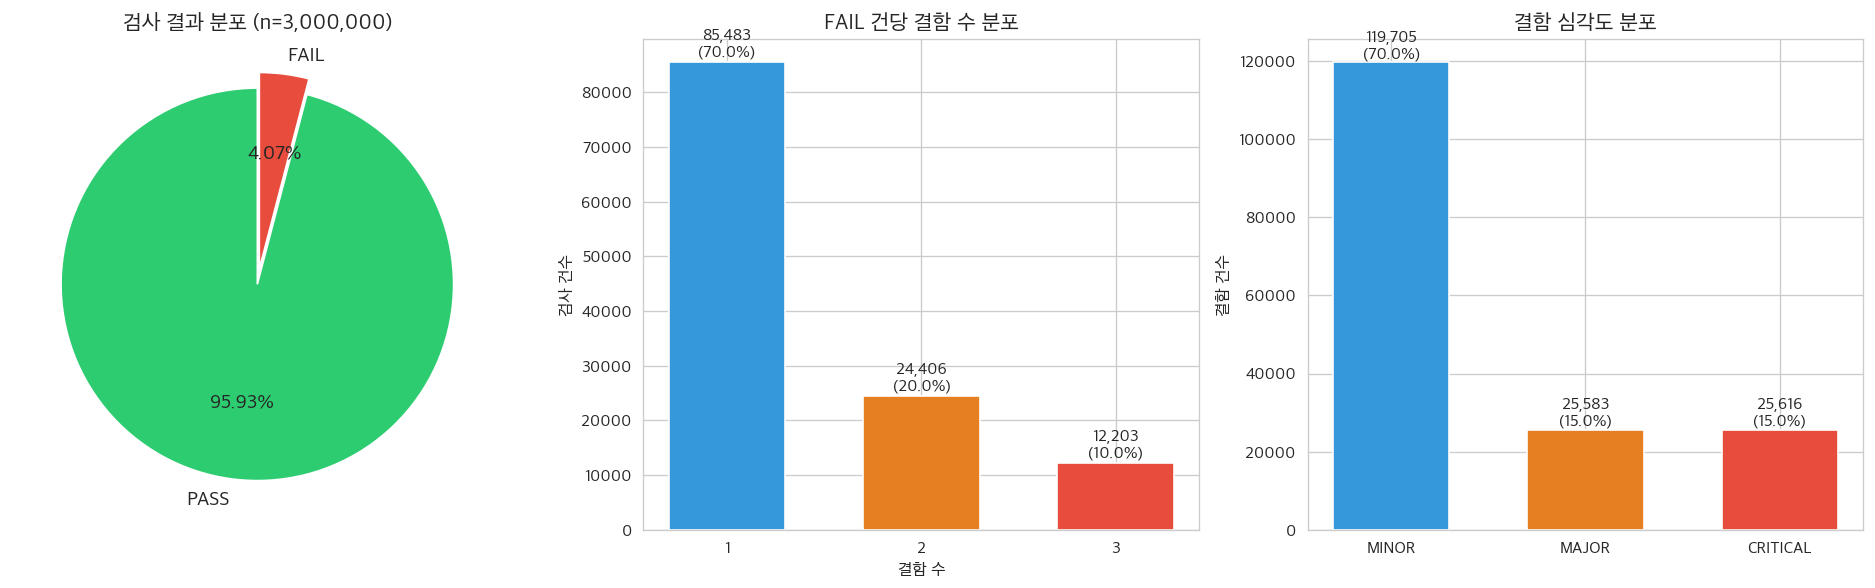

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1-1. PASS/FAIL 비율
result_vc = im['result'].value_counts()
colors_pf = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = axes[0].pie(
    result_vc, labels=['PASS', 'FAIL'], autopct='%1.2f%%',
    colors=colors_pf, startangle=90, explode=(0, 0.08),
    textprops={'fontsize': 12})
autotexts[1].set_fontweight('bold')
axes[0].set_title(f'검사 결과 분포 (n={len(im):,})', fontsize=13, fontweight='bold')

# 1-2. FAIL 건당 결함 수 분포
defects_per_fail = dd.groupby('inspection_id').size().value_counts().sort_index()
bars = axes[1].bar(defects_per_fail.index, defects_per_fail.values,
                   color=['#3498db', '#e67e22', '#e74c3c'], edgecolor='white', width=0.6)
for bar, v in zip(bars, defects_per_fail.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 1000,
                 f'{v:,}\n({v/defects_per_fail.sum()*100:.1f}%)',
                 ha='center', fontsize=10)
axes[1].set_xlabel('결함 수')
axes[1].set_ylabel('검사 건수')
axes[1].set_title('FAIL 건당 결함 수 분포', fontsize=13, fontweight='bold')
axes[1].set_xticks([1, 2, 3])

# 1-3. 심각도 분포
sev_order = ['MINOR', 'MAJOR', 'CRITICAL']
sev_colors = {'MINOR': '#3498db', 'MAJOR': '#e67e22', 'CRITICAL': '#e74c3c'}
sev_vc = dd['severity'].value_counts().reindex(sev_order)
bars2 = axes[2].bar(sev_order, sev_vc.values,
                    color=[sev_colors[s] for s in sev_order], edgecolor='white', width=0.6)
for bar, v in zip(bars2, sev_vc.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, v + 1000,
                 f'{v:,}\n({v/len(dd)*100:.1f}%)', ha='center', fontsize=10)
axes[2].set_ylabel('결함 건수')
axes[2].set_title('결함 심각도 분포', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### 인사이트
- **전체 불량률 4.07%** — 업계 일반적인 도장 불량률(3~5%) 범위 내이나, 건당 재작업 비용을 고려하면 개선 여지가 있음
- **FAIL 1건당 평균 1.4개 결함** — 30%가 다중 결함(2~3개). 하나의 불량이 발견되면 추가 결함도 동반될 가능성이 높음
- **MINOR 70%** vs CRITICAL+MAJOR 30% — 경미한 결함이 대다수이나, CRITICAL(GAP, CRK, WLD)은 건당 재작업 시간이 60~120분으로 비용 임팩트가 큼

---
## 2. 시간대별 불량률 패턴 (핵심 발견)

교대조(Shift)와 시간대별 불량률을 분석하여 **언제** 불량이 집중되는지 확인한다.

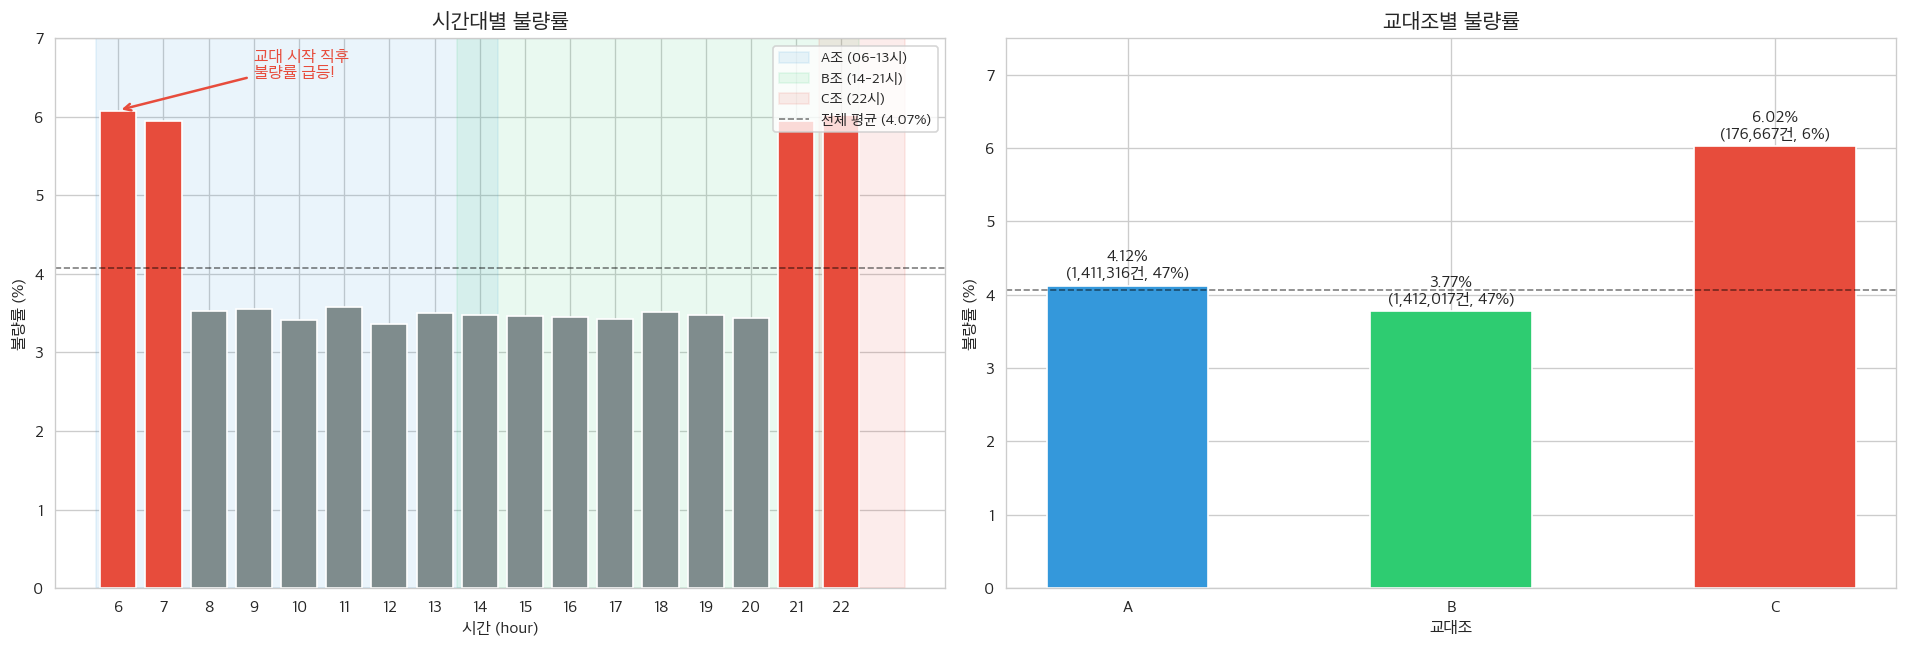

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# 2-1. 시간대별 불량률
hourly = im.groupby('hour').agg(
    total=('is_fail', 'count'), fails=('is_fail', 'sum')
)
hourly['fail_rate'] = hourly['fails'] / hourly['total'] * 100

# 교대조 영역 표시
shift_spans = {'A조 (06-13시)': (6, 13.9, '#3498db'),
               'B조 (14-21시)': (14, 21.9, '#2ecc71'),
               'C조 (22시)':    (22, 22.9, '#e74c3c')}

for label, (s, e, c) in shift_spans.items():
    axes[0].axvspan(s - 0.5, e + 0.5, alpha=0.10, color=c, label=label)

bars = axes[0].bar(hourly.index, hourly['fail_rate'],
                   color=['#e74c3c' if h in [6, 7, 21, 22] else '#7f8c8d' for h in hourly.index],
                   edgecolor='white', width=0.8)
axes[0].axhline(y=4.07, color='black', linestyle='--', linewidth=1, alpha=0.5, label='전체 평균 (4.07%)')
axes[0].set_xlabel('시간 (hour)')
axes[0].set_ylabel('불량률 (%)')
axes[0].set_title('시간대별 불량률', fontsize=13, fontweight='bold')
axes[0].set_xticks(hourly.index)
axes[0].legend(fontsize=9, loc='upper right')
axes[0].set_ylim(0, 7)

# 강조 annotation
axes[0].annotate('교대 시작 직후\n불량률 급등!',
                 xy=(6, 6.08), xytext=(9, 6.5),
                 arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.5),
                 fontsize=10, color='#e74c3c', fontweight='bold')

# 2-2. 교대조별 불량률
shift_stats = im.groupby('shift').agg(
    total=('is_fail', 'count'), fails=('is_fail', 'sum')
)
shift_stats['fail_rate'] = shift_stats['fails'] / shift_stats['total'] * 100
shift_stats['pct_of_total'] = shift_stats['total'] / shift_stats['total'].sum() * 100

shift_colors = {'A': '#3498db', 'B': '#2ecc71', 'C': '#e74c3c'}
bars2 = axes[1].bar(shift_stats.index, shift_stats['fail_rate'],
                    color=[shift_colors[s] for s in shift_stats.index],
                    edgecolor='white', width=0.5)
for bar, (idx, row) in zip(bars2, shift_stats.iterrows()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{row.fail_rate:.2f}%\n({row.total:,.0f}건, {row.pct_of_total:.0f}%)',
                 ha='center', fontsize=10, fontweight='bold')
axes[1].axhline(y=4.07, color='black', linestyle='--', linewidth=1, alpha=0.5)
axes[1].set_xlabel('교대조')
axes[1].set_ylabel('불량률 (%)')
axes[1].set_title('교대조별 불량률', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 7.5)

plt.tight_layout()
plt.show()

### 인사이트
- **C조(야간, 22시)의 불량률 6.02%로 전체 평균 대비 48% 높음** — 야간 교대의 피로, 조명 조건 변화, 인력 축소 등이 복합적으로 작용한 것으로 추정
- **각 교대 시작 직후(6~7시, 21시)에 불량률 급등** — 설비 워밍업, 교대 인수인계 과정의 품질 공백이 원인으로 보임. 8시 이후 안정화
- **B조(14~21시)가 3.77%로 가장 우수** — 설비가 충분히 안정화된 상태에서 운영되기 때문
- **비즈니스 제안**: C조 운영 시 품질 감독 강화, 교대 직후 30분간 집중 모니터링 프로토콜 도입 검토

---
## 3. 월별 불량률 추이 — 시계열 안정성 확인

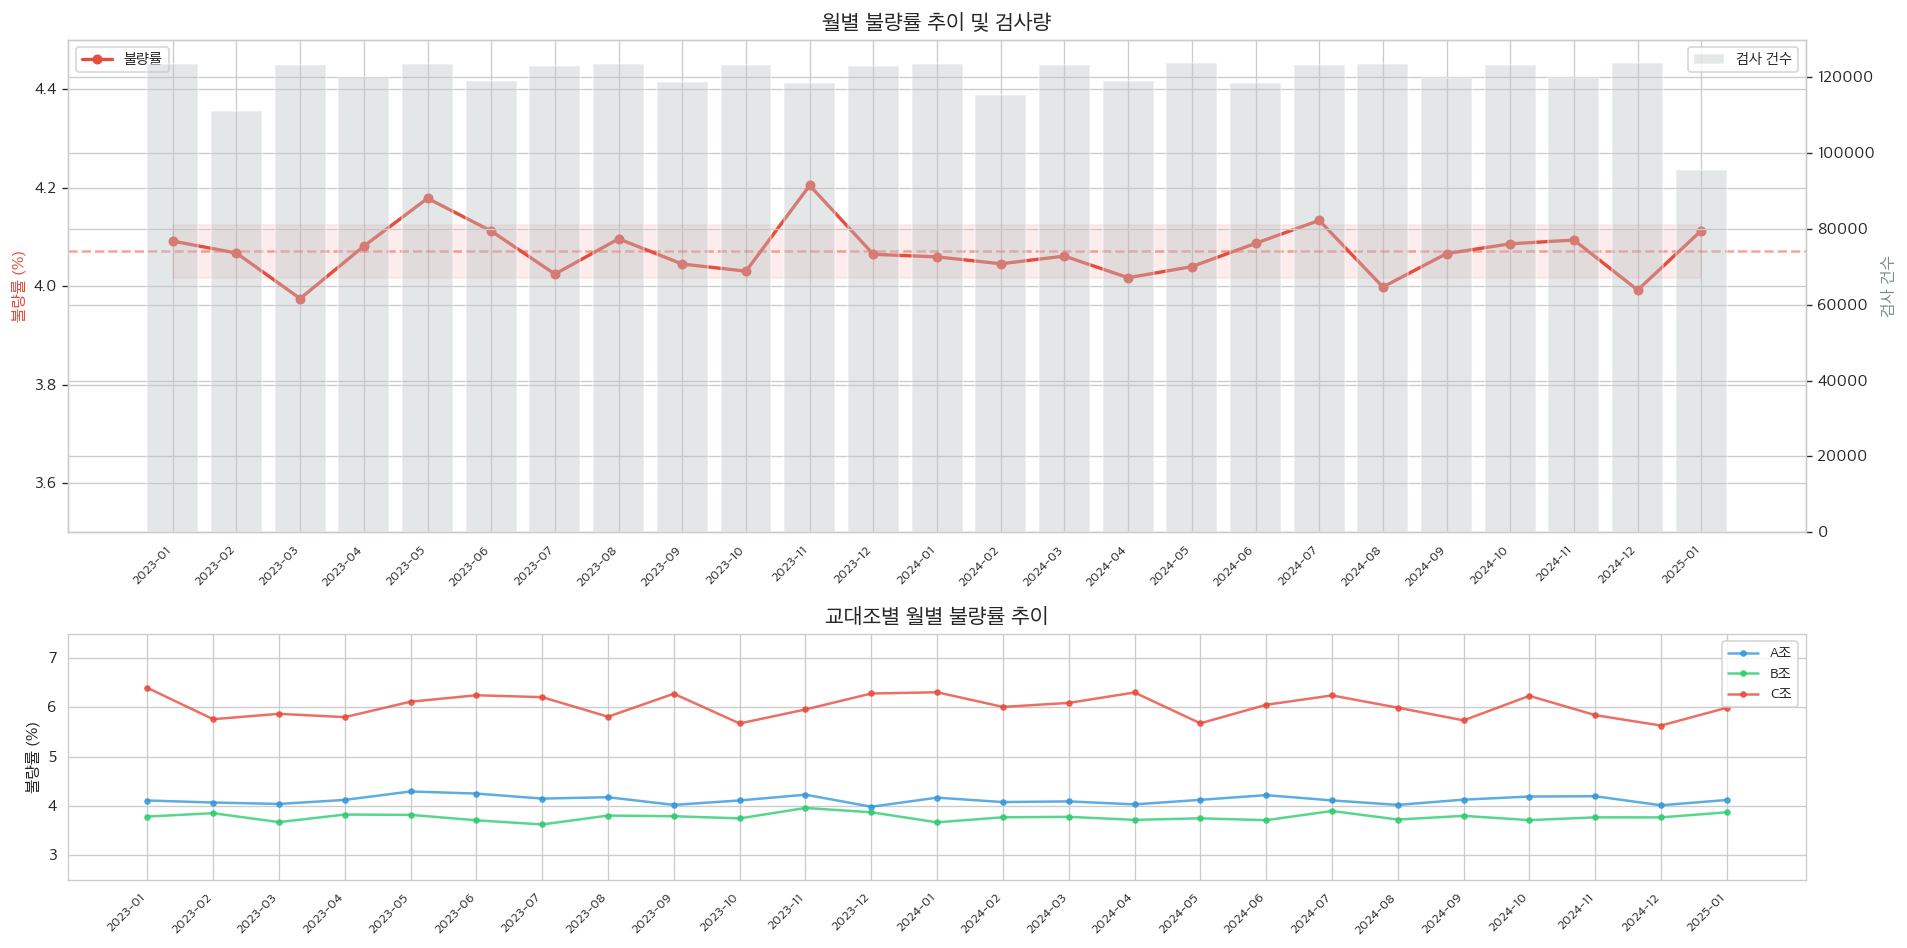

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8), gridspec_kw={'height_ratios': [2, 1]})

# 월별 집계
monthly = ds.groupby(ds['date'].dt.to_period('M')).agg(
    total=('total_inspections', 'sum'),
    fails=('fail_count', 'sum')
).reset_index()
monthly['fail_rate'] = monthly['fails'] / monthly['total'] * 100
monthly['date_str'] = monthly['date'].astype(str)

# 3-1. 불량률 추이 + 검사 건수
ax1 = axes[0]
ax1_twin = ax1.twinx()

ax1_twin.bar(range(len(monthly)), monthly['total'], color='#bdc3c7', alpha=0.4, label='검사 건수')
ax1.plot(range(len(monthly)), monthly['fail_rate'], 'o-', color='#e74c3c',
         linewidth=2, markersize=5, label='불량률', zorder=5)
ax1.axhline(y=monthly['fail_rate'].mean(), color='#e74c3c', linestyle='--', alpha=0.5)
ax1.fill_between(range(len(monthly)),
                 monthly['fail_rate'].mean() - monthly['fail_rate'].std(),
                 monthly['fail_rate'].mean() + monthly['fail_rate'].std(),
                 alpha=0.1, color='#e74c3c')

ax1.set_ylabel('불량률 (%)', color='#e74c3c')
ax1_twin.set_ylabel('검사 건수', color='#7f8c8d')
ax1.set_title('월별 불량률 추이 및 검사량', fontsize=13, fontweight='bold')
ax1.set_xticks(range(len(monthly)))
ax1.set_xticklabels(monthly['date_str'], rotation=45, ha='right', fontsize=8)
ax1.set_ylim(3.5, 4.5)
ax1.legend(loc='upper left', fontsize=9)
ax1_twin.legend(loc='upper right', fontsize=9)

# 3-2. 교대조별 월별 추이
for shift_val, color in [('A', '#3498db'), ('B', '#2ecc71'), ('C', '#e74c3c')]:
    shift_m = ds[ds['shift'] == shift_val].groupby(ds.loc[ds['shift'] == shift_val, 'date'].dt.to_period('M')).agg(
        total=('total_inspections', 'sum'), fails=('fail_count', 'sum')
    ).reset_index()
    shift_m['fail_rate'] = shift_m['fails'] / shift_m['total'] * 100
    axes[1].plot(range(len(shift_m)), shift_m['fail_rate'], 'o-',
                 color=color, linewidth=1.5, markersize=3, label=f'{shift_val}조', alpha=0.8)

axes[1].set_ylabel('불량률 (%)')
axes[1].set_title('교대조별 월별 불량률 추이', fontsize=13, fontweight='bold')
axes[1].set_xticks(range(len(monthly)))
axes[1].set_xticklabels(monthly['date_str'], rotation=45, ha='right', fontsize=8)
axes[1].legend(fontsize=9)
axes[1].set_ylim(2.5, 7.5)

plt.tight_layout()
plt.show()

### 인사이트
- **월별 불량률 3.97~4.20% 범위에서 매우 안정적** — 계절적 트렌드나 악화/개선 추세 없음. 공정이 통계적으로 관리(in-control) 상태
- **C조의 높은 불량률은 일시적이 아닌 구조적 패턴** — 25개월 전 기간에 걸쳐 일관되게 A/B조보다 높음
- 검사 건수도 월 12만건 수준으로 안정적이며, 검사량 변동이 불량률에 영향을 미치지 않음

---
## 4. 결함 유형 파레토 분석 — 핵심 결함 집중 관리 대상 식별

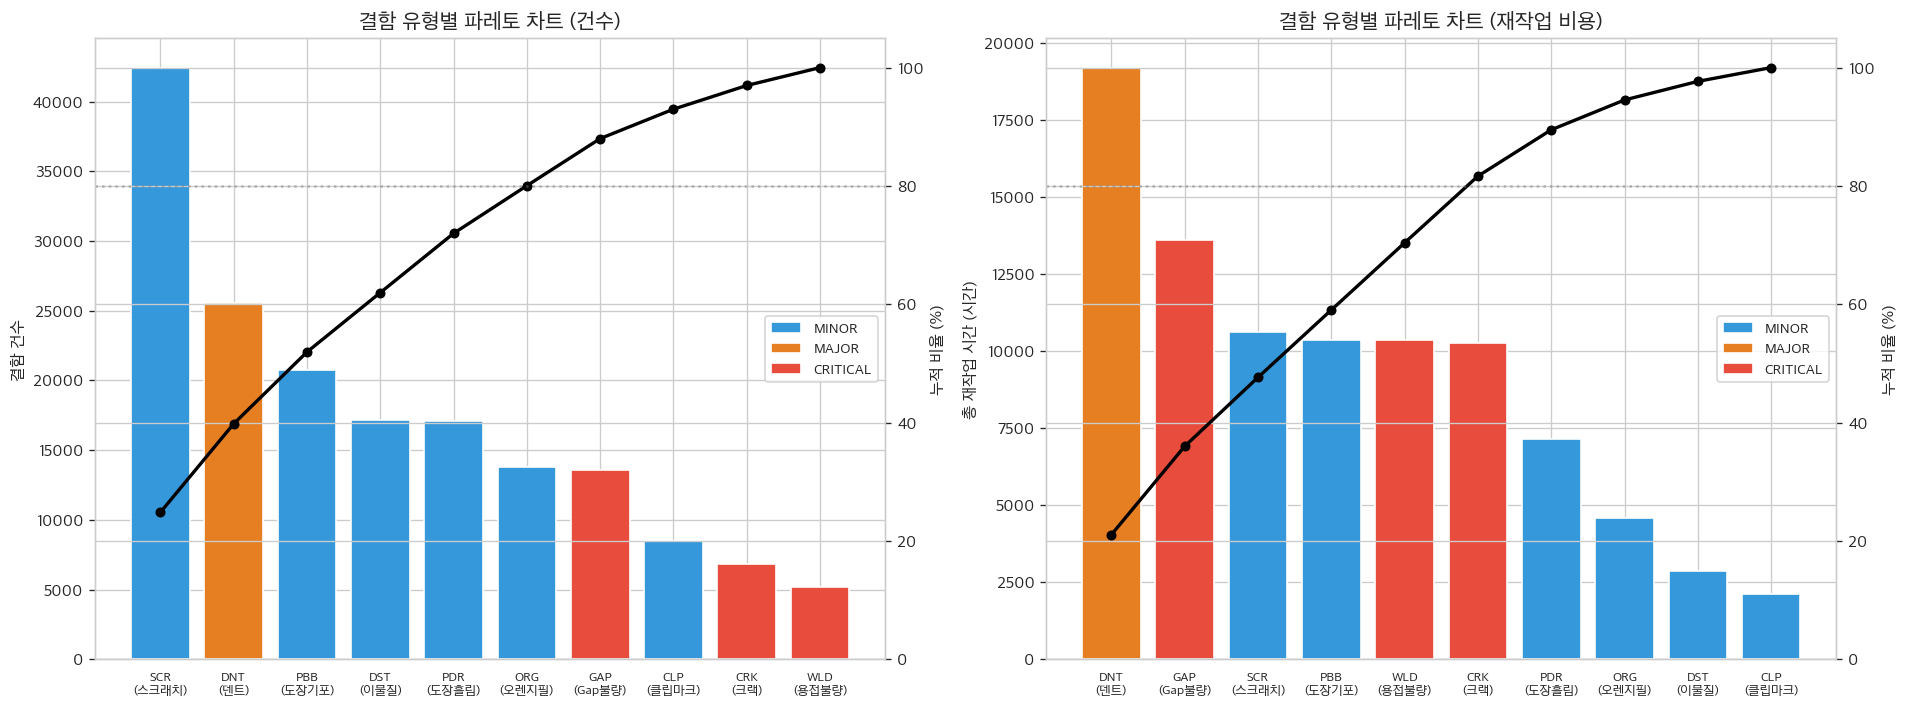

[ 결함 유형별 요약 ]
defect_type_code severity  count     pct  rework_hours
             SCR    MINOR  42432 24.8000         10608
             DNT    MAJOR  25583 15.0000         19187
             PBB    MINOR  20738 12.1000         10369
             DST    MINOR  17150 10.0000          2858
             PDR    MINOR  17111 10.0000          7130
             ORG    MINOR  13782  8.1000          4594
             GAP CRITICAL  13605  8.0000         13605
             CLP    MINOR   8492  5.0000          2123
             CRK CRITICAL   6841  4.0000         10262
             WLD CRITICAL   5170  3.0000         10340


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 결함 유형별 집계 (마스터 조인)
defect_stats = dd.merge(m_defect[['defect_type_code', 'std_rework_time_min']], on='defect_type_code')
type_agg = defect_stats.groupby(['defect_type_code', 'severity']).agg(
    count=('defect_id', 'count'),
    total_rework=('estimated_rework_min', 'sum'),
    avg_area=('area_mm2', 'mean')
).reset_index().sort_values('count', ascending=False)

# 4-1. 파레토 차트 (건수 기준)
sev_color_map = {'MINOR': '#3498db', 'MAJOR': '#e67e22', 'CRITICAL': '#e74c3c'}
type_names = dd.groupby('defect_type_code')['defect_type_name'].first()
labels = [f"{row.defect_type_code}\n({type_names[row.defect_type_code]})" for _, row in type_agg.iterrows()]
bar_colors = [sev_color_map[row.severity] for _, row in type_agg.iterrows()]

bars = axes[0].bar(range(len(type_agg)), type_agg['count'], color=bar_colors, edgecolor='white')
cumulative = type_agg['count'].cumsum() / type_agg['count'].sum() * 100
ax_cum = axes[0].twinx()
ax_cum.plot(range(len(type_agg)), cumulative.values, 'ko-', markersize=5, linewidth=2)
ax_cum.axhline(y=80, color='gray', linestyle=':', alpha=0.5)
ax_cum.set_ylabel('누적 비율 (%)')
ax_cum.set_ylim(0, 105)

axes[0].set_xticks(range(len(type_agg)))
axes[0].set_xticklabels(labels, fontsize=8)
axes[0].set_ylabel('결함 건수')
axes[0].set_title('결함 유형별 파레토 차트 (건수)', fontsize=13, fontweight='bold')

# 범례
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=s) for s, c in sev_color_map.items()]
axes[0].legend(handles=legend_elements, loc='center right', fontsize=9)

# 4-2. 파레토 차트 (재작업 시간 기준)
type_rework = type_agg.sort_values('total_rework', ascending=False)
labels_r = [f"{row.defect_type_code}\n({type_names[row.defect_type_code]})" for _, row in type_rework.iterrows()]
bar_colors_r = [sev_color_map[row.severity] for _, row in type_rework.iterrows()]

bars2 = axes[1].bar(range(len(type_rework)), type_rework['total_rework'] / 60,
                    color=bar_colors_r, edgecolor='white')
cumulative_r = type_rework['total_rework'].cumsum() / type_rework['total_rework'].sum() * 100
ax_cum2 = axes[1].twinx()
ax_cum2.plot(range(len(type_rework)), cumulative_r.values, 'ko-', markersize=5, linewidth=2)
ax_cum2.axhline(y=80, color='gray', linestyle=':', alpha=0.5)
ax_cum2.set_ylabel('누적 비율 (%)')
ax_cum2.set_ylim(0, 105)

axes[1].set_xticks(range(len(type_rework)))
axes[1].set_xticklabels(labels_r, fontsize=8)
axes[1].set_ylabel('총 재작업 시간 (시간)')
axes[1].set_title('결함 유형별 파레토 차트 (재작업 비용)', fontsize=13, fontweight='bold')
axes[1].legend(handles=legend_elements, loc='center right', fontsize=9)

plt.tight_layout()
plt.show()

# 요약 테이블
print("[ 결함 유형별 요약 ]")
summary = type_agg.copy()
summary['rework_hours'] = (summary['total_rework'] / 60).round(0).astype(int)
summary['pct'] = (summary['count'] / summary['count'].sum() * 100).round(1)
print(summary[['defect_type_code','severity','count','pct','rework_hours']].to_string(index=False))

### 인사이트
- **건수 기준 vs 비용 기준 우선순위가 다름** — 스크래치(SCR)는 건수 1위(24.8%)이지만 재작업 비용에서는 덴트(DNT)가 1위
- **CRITICAL 결함(WLD, CRK, GAP)은 건수는 적지만 비용 임팩트가 큼** — 용접불량(WLD)은 전체의 3%에 불과하지만 건당 120분 소요
- **상위 5개 결함이 건수의 72%, 재작업 비용의 77%를 차지** — 파레토 법칙에 부합. SCR, DNT, PBB, DST, PDR에 집중 관리 필요
- **비즈니스 제안**: 비용 관점에서는 DNT(덴트) 예방이 최우선. 건수 관점에서는 SCR(스크래치) 저감 대책이 효과적

---
## 5. 결함 유형 × 검사 구역 히트맵

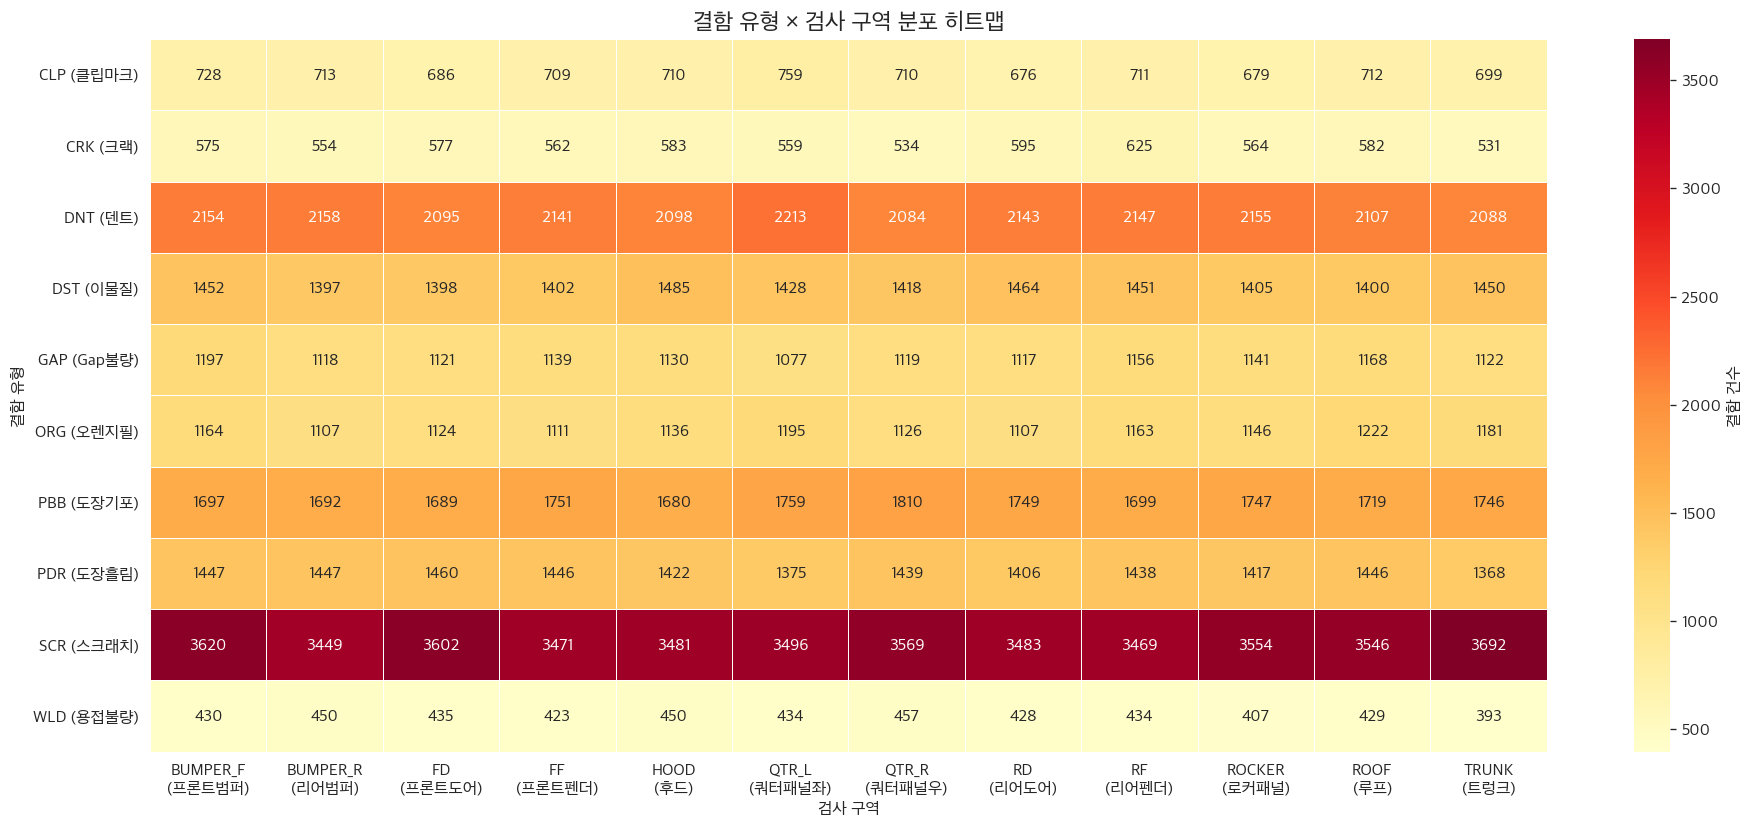

In [7]:
# 결함유형 × 구역 크로스탭
zone_names = m_zone.set_index('zone_code')['zone_name']
type_name_map = m_defect.set_index('defect_type_code')['defect_type_name']

ct = pd.crosstab(dd['defect_type_code'], dd['zone_code'])
# 행/열 라벨을 한글로
ct.index = [f"{idx} ({type_name_map.get(idx, idx)})" for idx in ct.index]
ct.columns = [f"{col}\n({zone_names.get(col, col)})" for col in ct.columns]

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': '결함 건수'})
ax.set_title('결함 유형 × 검사 구역 분포 히트맵', fontsize=14, fontweight='bold')
ax.set_xlabel('검사 구역')
ax.set_ylabel('결함 유형')
plt.tight_layout()
plt.show()

### 인사이트
- **구역 간 분포가 거의 균등** — 특정 구역에 특정 결함이 집중되는 패턴은 약함 (시뮬레이션 데이터 특성)
- **SCR(스크래치)는 모든 구역에서 3,400~3,700건으로 압도적 1위** — 구역에 무관하게 발생하는 범용적 결함
- **DNT(덴트)도 전 구역 2,084~2,213건으로 고르게 분포** — 도장 공정보다는 차체 핸들링 과정의 문제로 추정

---
## 6. 결함 동시발생(Co-occurrence) 분석

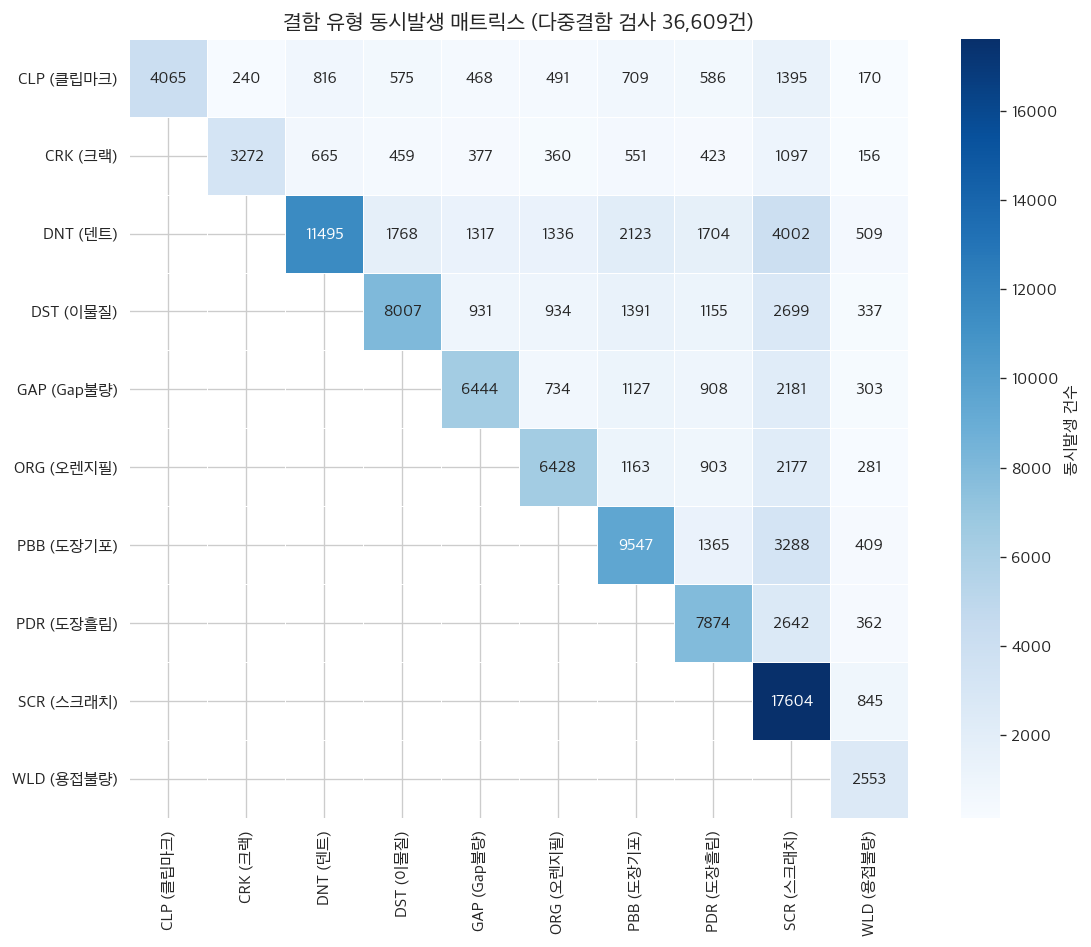


[ Top 10 결함 동시발생 조합 ]
  DNT(덴트) + SCR(스크래치): 4,002건
  PBB(도장기포) + SCR(스크래치): 3,288건
  DST(이물질) + SCR(스크래치): 2,699건
  PDR(도장흘림) + SCR(스크래치): 2,642건
  GAP(Gap불량) + SCR(스크래치): 2,181건
  ORG(오렌지필) + SCR(스크래치): 2,177건
  DNT(덴트) + PBB(도장기포): 2,123건
  DNT(덴트) + DST(이물질): 1,768건
  DNT(덴트) + PDR(도장흘림): 1,704건
  CLP(클립마크) + SCR(스크래치): 1,395건


In [8]:
# 다중 결함 동시발생 매트릭스
from itertools import combinations

multi_defects = dd.groupby('inspection_id')['defect_type_code'].apply(list)
multi_defects = multi_defects[multi_defects.apply(len) > 1]

# Co-occurrence 매트릭스
codes = sorted(m_defect['defect_type_code'].tolist())
cooc = pd.DataFrame(0, index=codes, columns=codes)
for defect_list in multi_defects:
    unique_types = list(set(defect_list))
    for a, b in combinations(unique_types, 2):
        cooc.loc[a, b] += 1
        cooc.loc[b, a] += 1
    for t in unique_types:
        cooc.loc[t, t] += 1  # self-occurrence count

# 대각선 제거하고 상삼각만 표시
mask = np.tril(np.ones_like(cooc, dtype=bool))
np.fill_diagonal(mask, False)  # 대각선은 보여줌

fig, ax = plt.subplots(figsize=(10, 8))
# 라벨
idx_labels = [f"{c} ({type_name_map[c]})" for c in codes]
cooc_display = cooc.copy()
cooc_display.index = idx_labels
cooc_display.columns = idx_labels

sns.heatmap(cooc_display, mask=mask, annot=True, fmt='d', cmap='Blues', ax=ax,
            linewidths=0.5, linecolor='white', square=True,
            cbar_kws={'label': '동시발생 건수'})
ax.set_title('결함 유형 동시발생 매트릭스 (다중결함 검사 36,609건)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Top 10 pairs
from collections import Counter
pair_counts = Counter()
for defect_list in multi_defects:
    unique_types = sorted(set(defect_list))
    for a, b in combinations(unique_types, 2):
        pair_counts[(a, b)] += 1

print("\n[ Top 10 결함 동시발생 조합 ]")
for (a, b), cnt in pair_counts.most_common(10):
    print(f"  {a}({type_name_map[a]}) + {b}({type_name_map[b]}): {cnt:,}건")

### 인사이트
- **SCR(스크래치)가 거의 모든 다른 결함과 함께 발생** — Top 10 조합 중 7개가 SCR 포함. 스크래치는 다른 결함의 "동반자" 역할
- **DNT + SCR (4,002건)이 가장 빈번한 조합** — 물리적 충격이 덴트와 스크래치를 동시에 유발
- **PBB + SCR (3,288건)** — 도장기포가 있는 영역이 후속 공정에서 스크래치에 취약한 것으로 추정
- **비즈니스 제안**: SCR 예방 대책이 전체 다중결함 발생을 줄이는 레버리지 포인트

---
## 7. 공장/라인별 불량률 비교

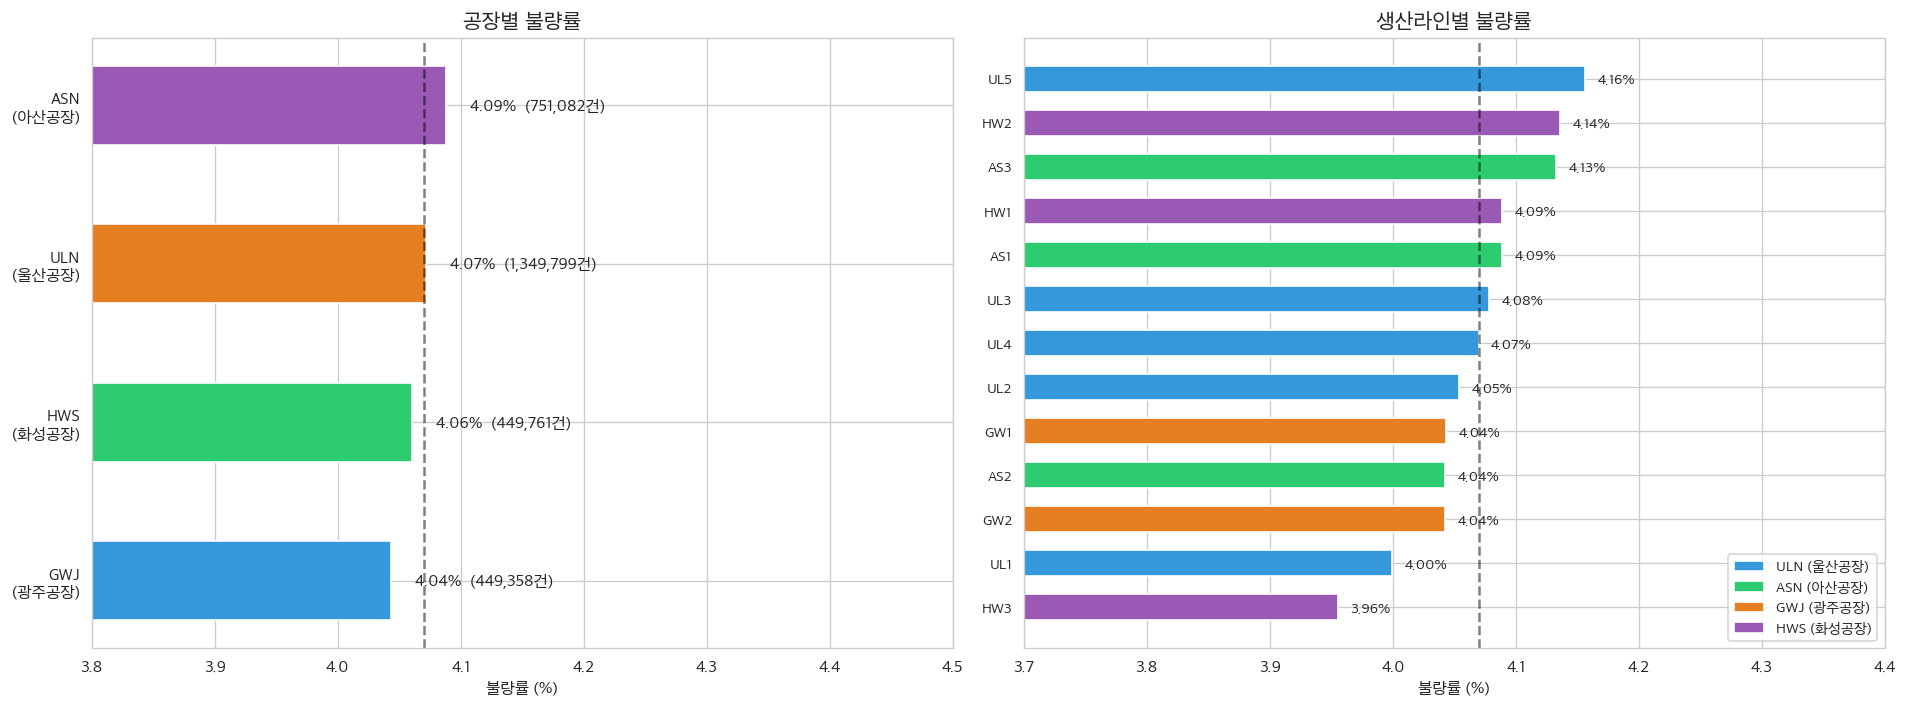

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 7-1. 공장별 불량률 + 검사량
plant_names = m_plant.drop_duplicates('plant_code').set_index('plant_code')['plant_name']
plant_stats = im.groupby('plant_code').agg(
    total=('is_fail', 'count'), fails=('is_fail', 'sum')
)
plant_stats['fail_rate'] = plant_stats['fails'] / plant_stats['total'] * 100
plant_stats = plant_stats.sort_values('fail_rate', ascending=True)

colors_plant = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6']
y_pos = range(len(plant_stats))
bars = axes[0].barh(y_pos, plant_stats['fail_rate'], color=colors_plant, edgecolor='white', height=0.5)
for i, (idx, row) in enumerate(plant_stats.iterrows()):
    axes[0].text(row.fail_rate + 0.02, i,
                 f"{row.fail_rate:.2f}%  ({row.total:,.0f}건)",
                 va='center', fontsize=10, fontweight='bold')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels([f"{idx}\n({plant_names.get(idx, idx)})" for idx in plant_stats.index])
axes[0].set_xlabel('불량률 (%)')
axes[0].set_title('공장별 불량률', fontsize=13, fontweight='bold')
axes[0].set_xlim(3.8, 4.5)
axes[0].axvline(x=4.07, color='black', linestyle='--', alpha=0.5)

# 7-2. 라인별 불량률 (공장 색상 구분)
line_stats = im.groupby(['plant_code', 'line_code']).agg(
    total=('is_fail', 'count'), fails=('is_fail', 'sum')
)
line_stats['fail_rate'] = line_stats['fails'] / line_stats['total'] * 100
line_stats = line_stats.sort_values('fail_rate', ascending=True).reset_index()

plant_color_map = {'ULN': '#3498db', 'ASN': '#2ecc71', 'GWJ': '#e67e22', 'HWS': '#9b59b6'}
y_pos2 = range(len(line_stats))
line_colors = [plant_color_map[p] for p in line_stats['plant_code']]
bars2 = axes[1].barh(y_pos2, line_stats['fail_rate'], color=line_colors, edgecolor='white', height=0.6)
for i, row in line_stats.iterrows():
    axes[1].text(row.fail_rate + 0.01, i, f"{row.fail_rate:.2f}%", va='center', fontsize=9)
axes[1].set_yticks(y_pos2)
axes[1].set_yticklabels(line_stats['line_code'], fontsize=9)
axes[1].set_xlabel('불량률 (%)')
axes[1].set_title('생산라인별 불량률', fontsize=13, fontweight='bold')
axes[1].set_xlim(3.7, 4.4)
axes[1].axvline(x=4.07, color='black', linestyle='--', alpha=0.5)
legend_p = [Patch(facecolor=c, label=f"{k} ({plant_names.get(k,k)})") for k, c in plant_color_map.items()]
axes[1].legend(handles=legend_p, fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

### 인사이트
- **공장 간 불량률 차이는 미미** (4.04~4.09%) — 모든 공장이 유사한 품질 수준 유지
- **라인 단위에서는 약간의 차이** — UL5(4.16%), HW2(4.14%), AS3(4.13%)이 상위, HW3(3.96%), UL1(4.00%)이 하위
- 라인 간 최대 편차 0.20%p는 통계적으로 유의미할 수 있으나, 비즈니스 임팩트는 제한적
- 울산공장(ULN)이 전체 검사의 45%를 담당하는 최대 공장

---
## 8. 환경 요인(온도/습도)과 불량률의 관계

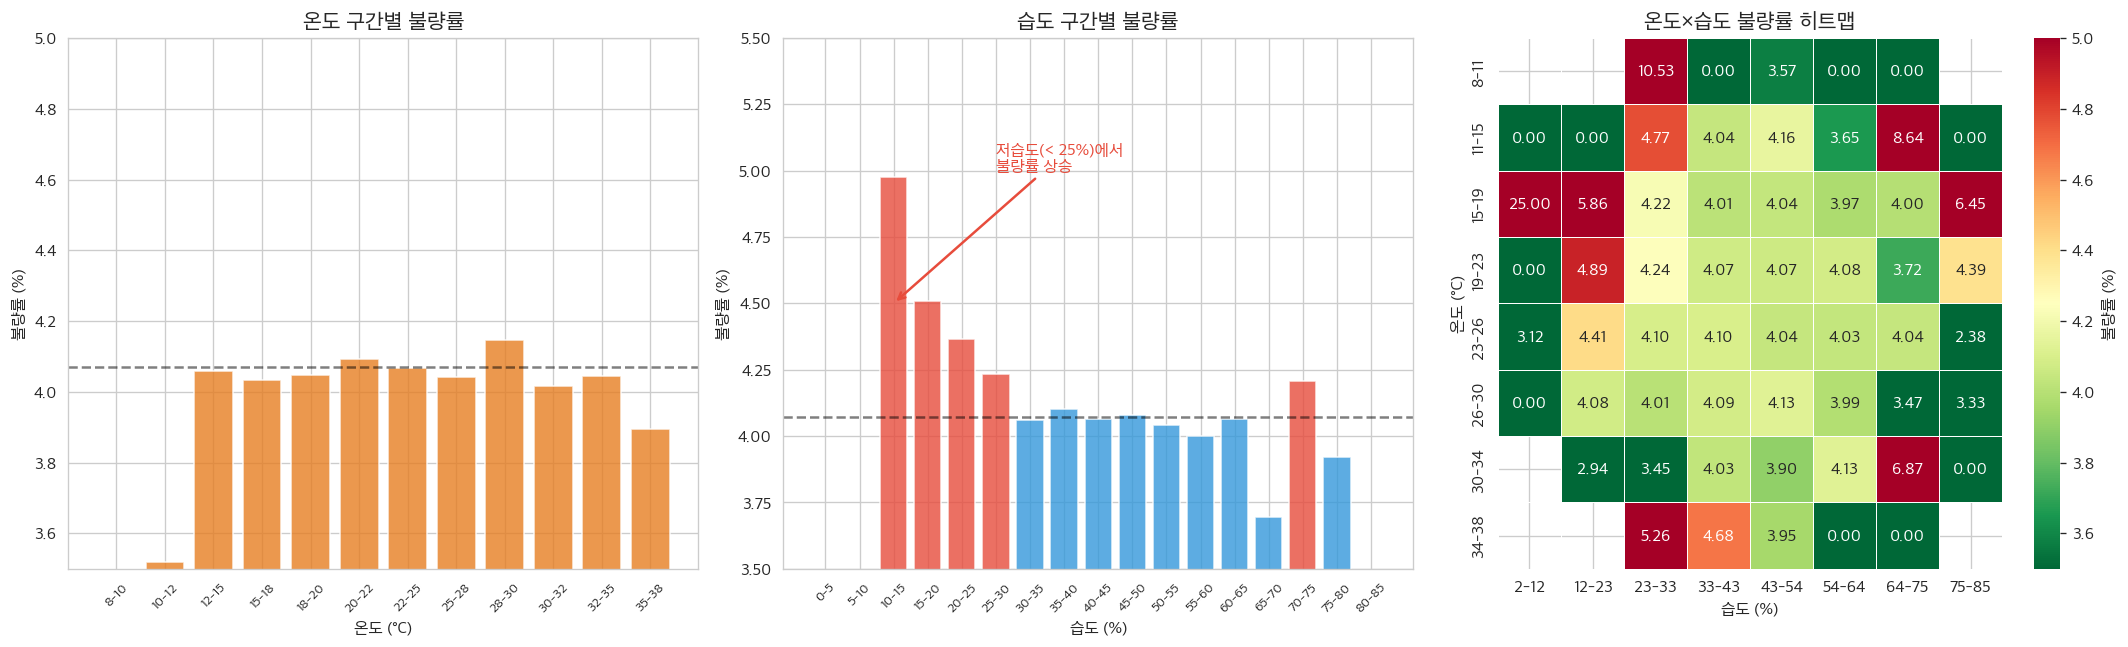

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# 8-1. 온도 구간별 불량률
temp_bins = pd.cut(im['ambient_temp_c'], bins=np.arange(5, 40, 2.5))
temp_fail = im.groupby(temp_bins, observed=True).agg(
    total=('is_fail', 'count'), fails=('is_fail', 'sum')
)
temp_fail['fail_rate'] = temp_fail['fails'] / temp_fail['total'] * 100
x_labels = [f"{i.left:.0f}-{i.right:.0f}" for i in temp_fail.index]

axes[0].bar(range(len(temp_fail)), temp_fail['fail_rate'], color='#e67e22', edgecolor='white', alpha=0.8)
axes[0].axhline(y=4.07, color='black', linestyle='--', alpha=0.5)
axes[0].set_xticks(range(len(temp_fail)))
axes[0].set_xticklabels(x_labels, rotation=45, fontsize=8)
axes[0].set_xlabel('온도 (°C)')
axes[0].set_ylabel('불량률 (%)')
axes[0].set_title('온도 구간별 불량률', fontsize=13, fontweight='bold')
axes[0].set_ylim(3.5, 5.0)

# 8-2. 습도 구간별 불량률
hum_bins = pd.cut(im['humidity_pct'], bins=np.arange(0, 90, 5))
hum_fail = im.groupby(hum_bins, observed=True).agg(
    total=('is_fail', 'count'), fails=('is_fail', 'sum')
)
hum_fail['fail_rate'] = hum_fail['fails'] / hum_fail['total'] * 100
hum_labels = [f"{i.left:.0f}-{i.right:.0f}" for i in hum_fail.index]

colors_hum = ['#e74c3c' if fr > 4.2 else '#3498db' for fr in hum_fail['fail_rate']]
axes[1].bar(range(len(hum_fail)), hum_fail['fail_rate'], color=colors_hum, edgecolor='white', alpha=0.8)
axes[1].axhline(y=4.07, color='black', linestyle='--', alpha=0.5)
axes[1].set_xticks(range(len(hum_fail)))
axes[1].set_xticklabels(hum_labels, rotation=45, fontsize=8)
axes[1].set_xlabel('습도 (%)')
axes[1].set_ylabel('불량률 (%)')
axes[1].set_title('습도 구간별 불량률', fontsize=13, fontweight='bold')
axes[1].set_ylim(3.5, 5.5)

# 강조
axes[1].annotate('저습도(< 25%)에서\n불량률 상승',
                 xy=(2, 4.5), xytext=(5, 5.0),
                 arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.5),
                 fontsize=10, color='#e74c3c', fontweight='bold')

# 8-3. 온도-습도 2D 히트맵 (불량률)
im['temp_bin2'] = pd.cut(im['ambient_temp_c'], bins=8)
im['hum_bin2'] = pd.cut(im['humidity_pct'], bins=8)
heatmap_data = im.groupby(['temp_bin2', 'hum_bin2'], observed=True)['is_fail'].mean() * 100
heatmap_pivot = heatmap_data.unstack()
heatmap_pivot.index = [f"{i.left:.0f}-{i.right:.0f}" for i in heatmap_pivot.index]
heatmap_pivot.columns = [f"{i.left:.0f}-{i.right:.0f}" for i in heatmap_pivot.columns]

sns.heatmap(heatmap_pivot, annot=True, fmt='.2f', cmap='RdYlGn_r', ax=axes[2],
            linewidths=0.5, cbar_kws={'label': '불량률 (%)'}, vmin=3.5, vmax=5.0)
axes[2].set_xlabel('습도 (%)')
axes[2].set_ylabel('온도 (°C)')
axes[2].set_title('온도×습도 불량률 히트맵', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

### 인사이트
- **저습도(< 25%)에서 불량률이 4.3~4.5%로 유의미하게 상승** — 도장 공정에서 낮은 습도는 정전기 발생, 도료 건조 속도 변화로 품질에 악영향
- **온도는 불량률에 뚜렷한 영향 없음** — 전 구간에서 4.0~4.1%로 균일
- **2D 히트맵에서 저습도+극단 온도 구간이 위험 지대** — 겨울철 건조한 환경에서 특히 주의 필요
- **비즈니스 제안**: 도장 부스 습도 25% 이하 시 경고 알림 및 도료 배합 조정 프로토콜 적용

---
## 9. 작업자(Operator) 성과 분포

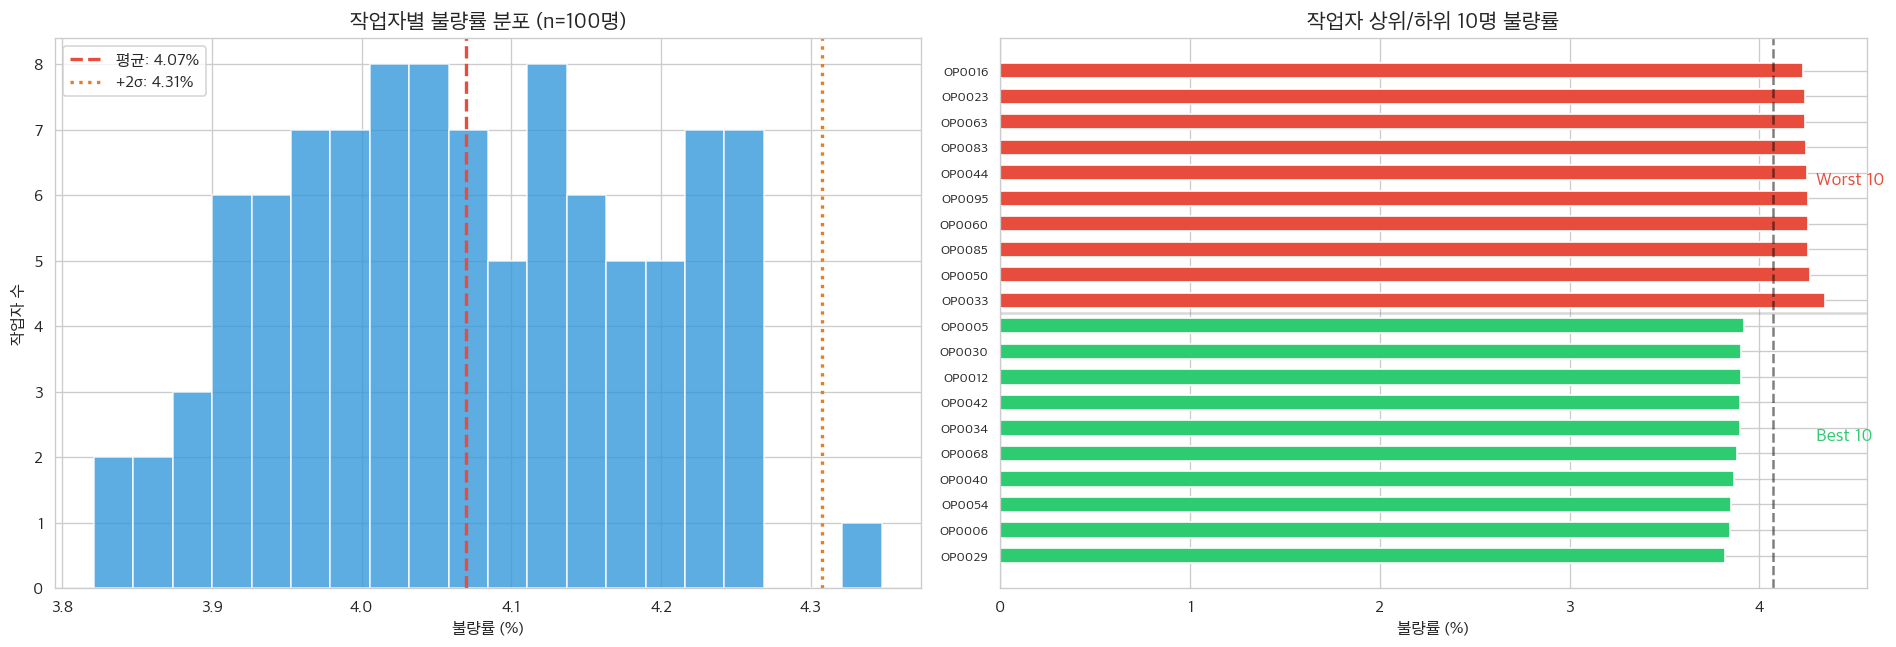

작업자 불량률 — min: 3.82%, max: 4.35%, std: 0.12%p, range: 0.53%p


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# 작업자별 불량률 계산
op_stats = im.groupby('operator_id').agg(
    total=('is_fail', 'count'), fails=('is_fail', 'sum')
)
op_stats['fail_rate'] = op_stats['fails'] / op_stats['total'] * 100

# 9-1. 작업자 불량률 분포 히스토그램
axes[0].hist(op_stats['fail_rate'], bins=20, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(x=op_stats['fail_rate'].mean(), color='#e74c3c', linestyle='--', linewidth=2,
                label=f'평균: {op_stats["fail_rate"].mean():.2f}%')
axes[0].axvline(x=op_stats['fail_rate'].mean() + 2*op_stats['fail_rate'].std(),
                color='#e67e22', linestyle=':', linewidth=2,
                label=f'+2σ: {op_stats["fail_rate"].mean() + 2*op_stats["fail_rate"].std():.2f}%')
axes[0].set_xlabel('불량률 (%)')
axes[0].set_ylabel('작업자 수')
axes[0].set_title(f'작업자별 불량률 분포 (n={len(op_stats)}명)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# 9-2. 상/하위 10명 비교
top10_worst = op_stats.nlargest(10, 'fail_rate')
top10_best = op_stats.nsmallest(10, 'fail_rate')
comparison = pd.concat([top10_best, top10_worst])

colors_op = ['#2ecc71'] * 10 + ['#e74c3c'] * 10
y_labels = [f"{idx}" for idx in comparison.index]
axes[1].barh(range(len(comparison)), comparison['fail_rate'],
             color=colors_op, edgecolor='white', height=0.6)
axes[1].axvline(x=4.07, color='black', linestyle='--', alpha=0.5, label='전체 평균')
axes[1].set_yticks(range(len(comparison)))
axes[1].set_yticklabels(y_labels, fontsize=8)
axes[1].set_xlabel('불량률 (%)')
axes[1].set_title('작업자 상위/하위 10명 불량률', fontsize=13, fontweight='bold')

# 구분선
axes[1].axhline(y=9.5, color='gray', linestyle='-', alpha=0.3)
axes[1].text(4.3, 4.5, 'Best 10', fontsize=11, color='#2ecc71', fontweight='bold')
axes[1].text(4.3, 14.5, 'Worst 10', fontsize=11, color='#e74c3c', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"작업자 불량률 — min: {op_stats['fail_rate'].min():.2f}%, max: {op_stats['fail_rate'].max():.2f}%, "
      f"std: {op_stats['fail_rate'].std():.2f}%p, range: {op_stats['fail_rate'].max()-op_stats['fail_rate'].min():.2f}%p")

### 인사이트
- **100명 작업자의 불량률 범위 3.82~4.35%** — 최대-최소 차이 0.53%p로 비교적 좁은 분포
- 작업자 간 표준편차 ~0.13%p — 개인 역량보다는 **공정/설비/환경 요인**이 불량률을 더 크게 좌우
- 극단적 성과 차이를 보이는 작업자는 없음 → 특정 작업자 교체보다는 시스템 개선이 효과적

---
## 10. AI 모델 신뢰도(Confidence) 분석 — 예측 모델 성능 진단

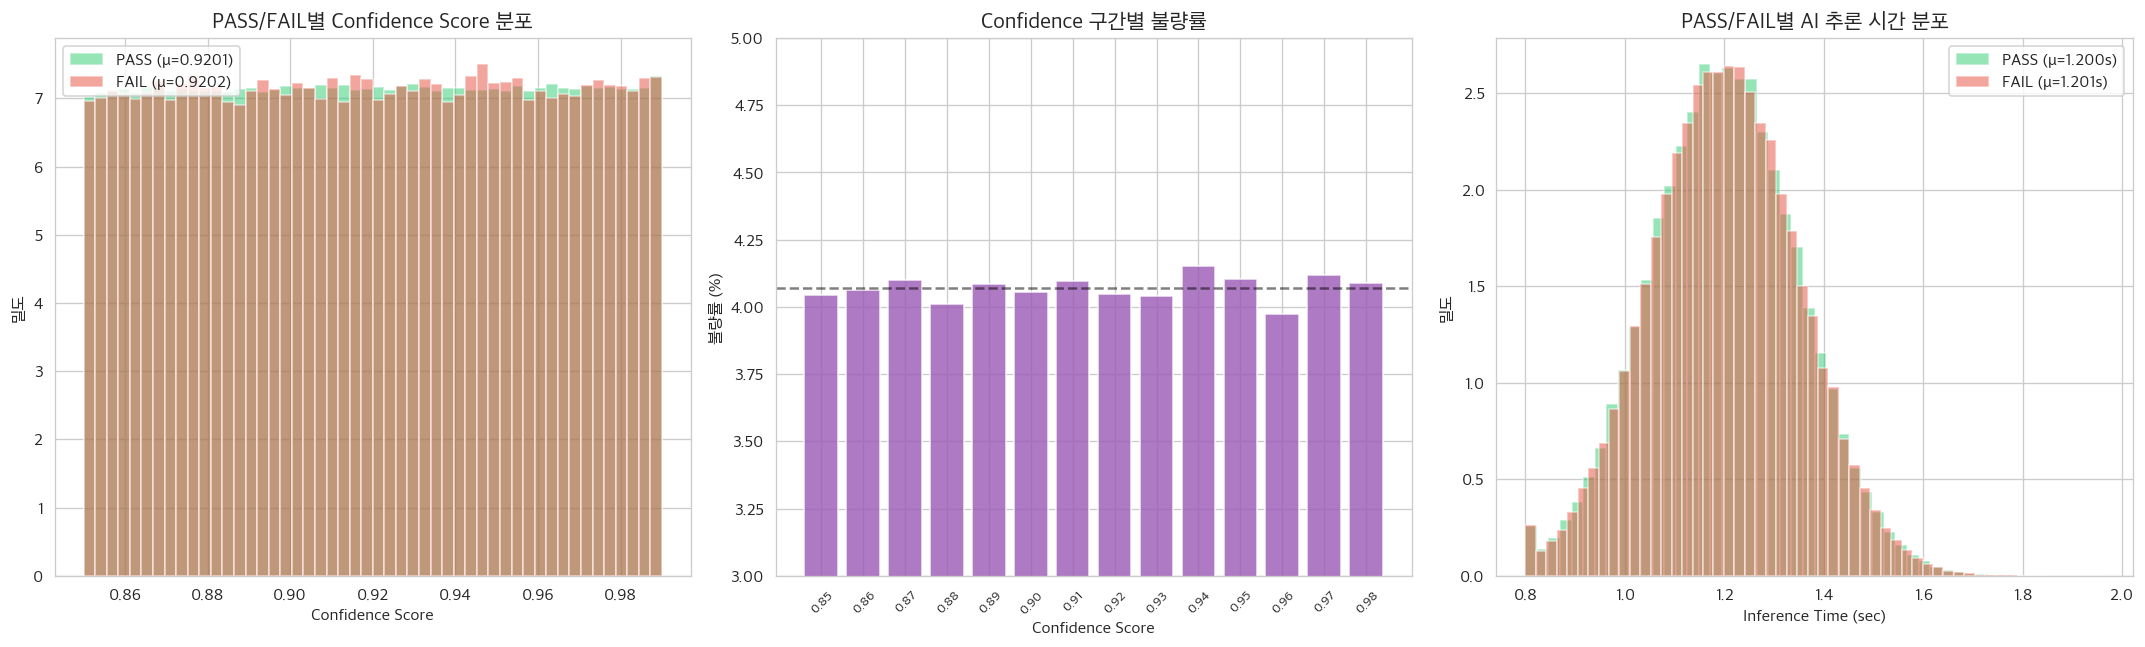

Confidence — PASS: 0.9201 ± 0.0404
Confidence — FAIL: 0.9202 ± 0.0404
차이: 0.0001 (거의 동일)


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# 10-1. PASS vs FAIL 신뢰도 분포 비교
for result, color, label in [('PASS', '#2ecc71', 'PASS'), ('FAIL', '#e74c3c', 'FAIL')]:
    subset = im.loc[im['result'] == result, 'confidence_score']
    axes[0].hist(subset, bins=50, alpha=0.5, color=color, label=f'{label} (μ={subset.mean():.4f})', density=True)
axes[0].set_xlabel('Confidence Score')
axes[0].set_ylabel('밀도')
axes[0].set_title('PASS/FAIL별 Confidence Score 분포', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# 10-2. Confidence 구간별 불량률
conf_bins = pd.cut(im['confidence_score'], bins=np.arange(0.85, 1.0, 0.01))
conf_fail = im.groupby(conf_bins, observed=True).agg(
    total=('is_fail', 'count'), fails=('is_fail', 'sum')
)
conf_fail['fail_rate'] = conf_fail['fails'] / conf_fail['total'] * 100
x_labels_c = [f"{i.left:.2f}" for i in conf_fail.index]

axes[1].bar(range(len(conf_fail)), conf_fail['fail_rate'], color='#9b59b6', edgecolor='white', alpha=0.8)
axes[1].axhline(y=4.07, color='black', linestyle='--', alpha=0.5)
axes[1].set_xticks(range(len(conf_fail)))
axes[1].set_xticklabels(x_labels_c, rotation=45, fontsize=8)
axes[1].set_xlabel('Confidence Score')
axes[1].set_ylabel('불량률 (%)')
axes[1].set_title('Confidence 구간별 불량률', fontsize=13, fontweight='bold')
axes[1].set_ylim(3.0, 5.0)

# 10-3. Inference Time 분포 (PASS vs FAIL)
for result, color, label in [('PASS', '#2ecc71', 'PASS'), ('FAIL', '#e74c3c', 'FAIL')]:
    subset = im.loc[im['result'] == result, 'inference_time_sec']
    axes[2].hist(subset, bins=50, alpha=0.5, color=color, label=f'{label} (μ={subset.mean():.3f}s)', density=True)
axes[2].set_xlabel('Inference Time (sec)')
axes[2].set_ylabel('밀도')
axes[2].set_title('PASS/FAIL별 AI 추론 시간 분포', fontsize=13, fontweight='bold')
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.show()

# 수치 비교
pass_conf = im.loc[im['result']=='PASS', 'confidence_score']
fail_conf = im.loc[im['result']=='FAIL', 'confidence_score']
print(f"Confidence — PASS: {pass_conf.mean():.4f} ± {pass_conf.std():.4f}")
print(f"Confidence — FAIL: {fail_conf.mean():.4f} ± {fail_conf.std():.4f}")
print(f"차이: {abs(pass_conf.mean()-fail_conf.mean()):.4f} (거의 동일)")

### 인사이트
- **Confidence Score가 PASS/FAIL을 구분하지 못함** — 두 그룹의 평균(0.9201 vs 0.9202), 표준편차(0.0404), 분포 형태가 거의 동일
- **Confidence 구간별 불량률도 편평** — 높은 신뢰도든 낮은 신뢰도든 불량률은 ~4%로 일정
- 이 confidence_score는 **모델의 예측 확률이 아니라 단순 메타데이터**로 보임. 실제 분류 모델링 시에는 이 피처를 그대로 사용하면 안 됨
- **Inference Time도 PASS/FAIL 간 차이 없음** — AI 모델이 불량 감지에 추가 시간을 쓰지 않는 구조

---
## 11. 결함 위치 공간 분석 (Spatial Heatmap)

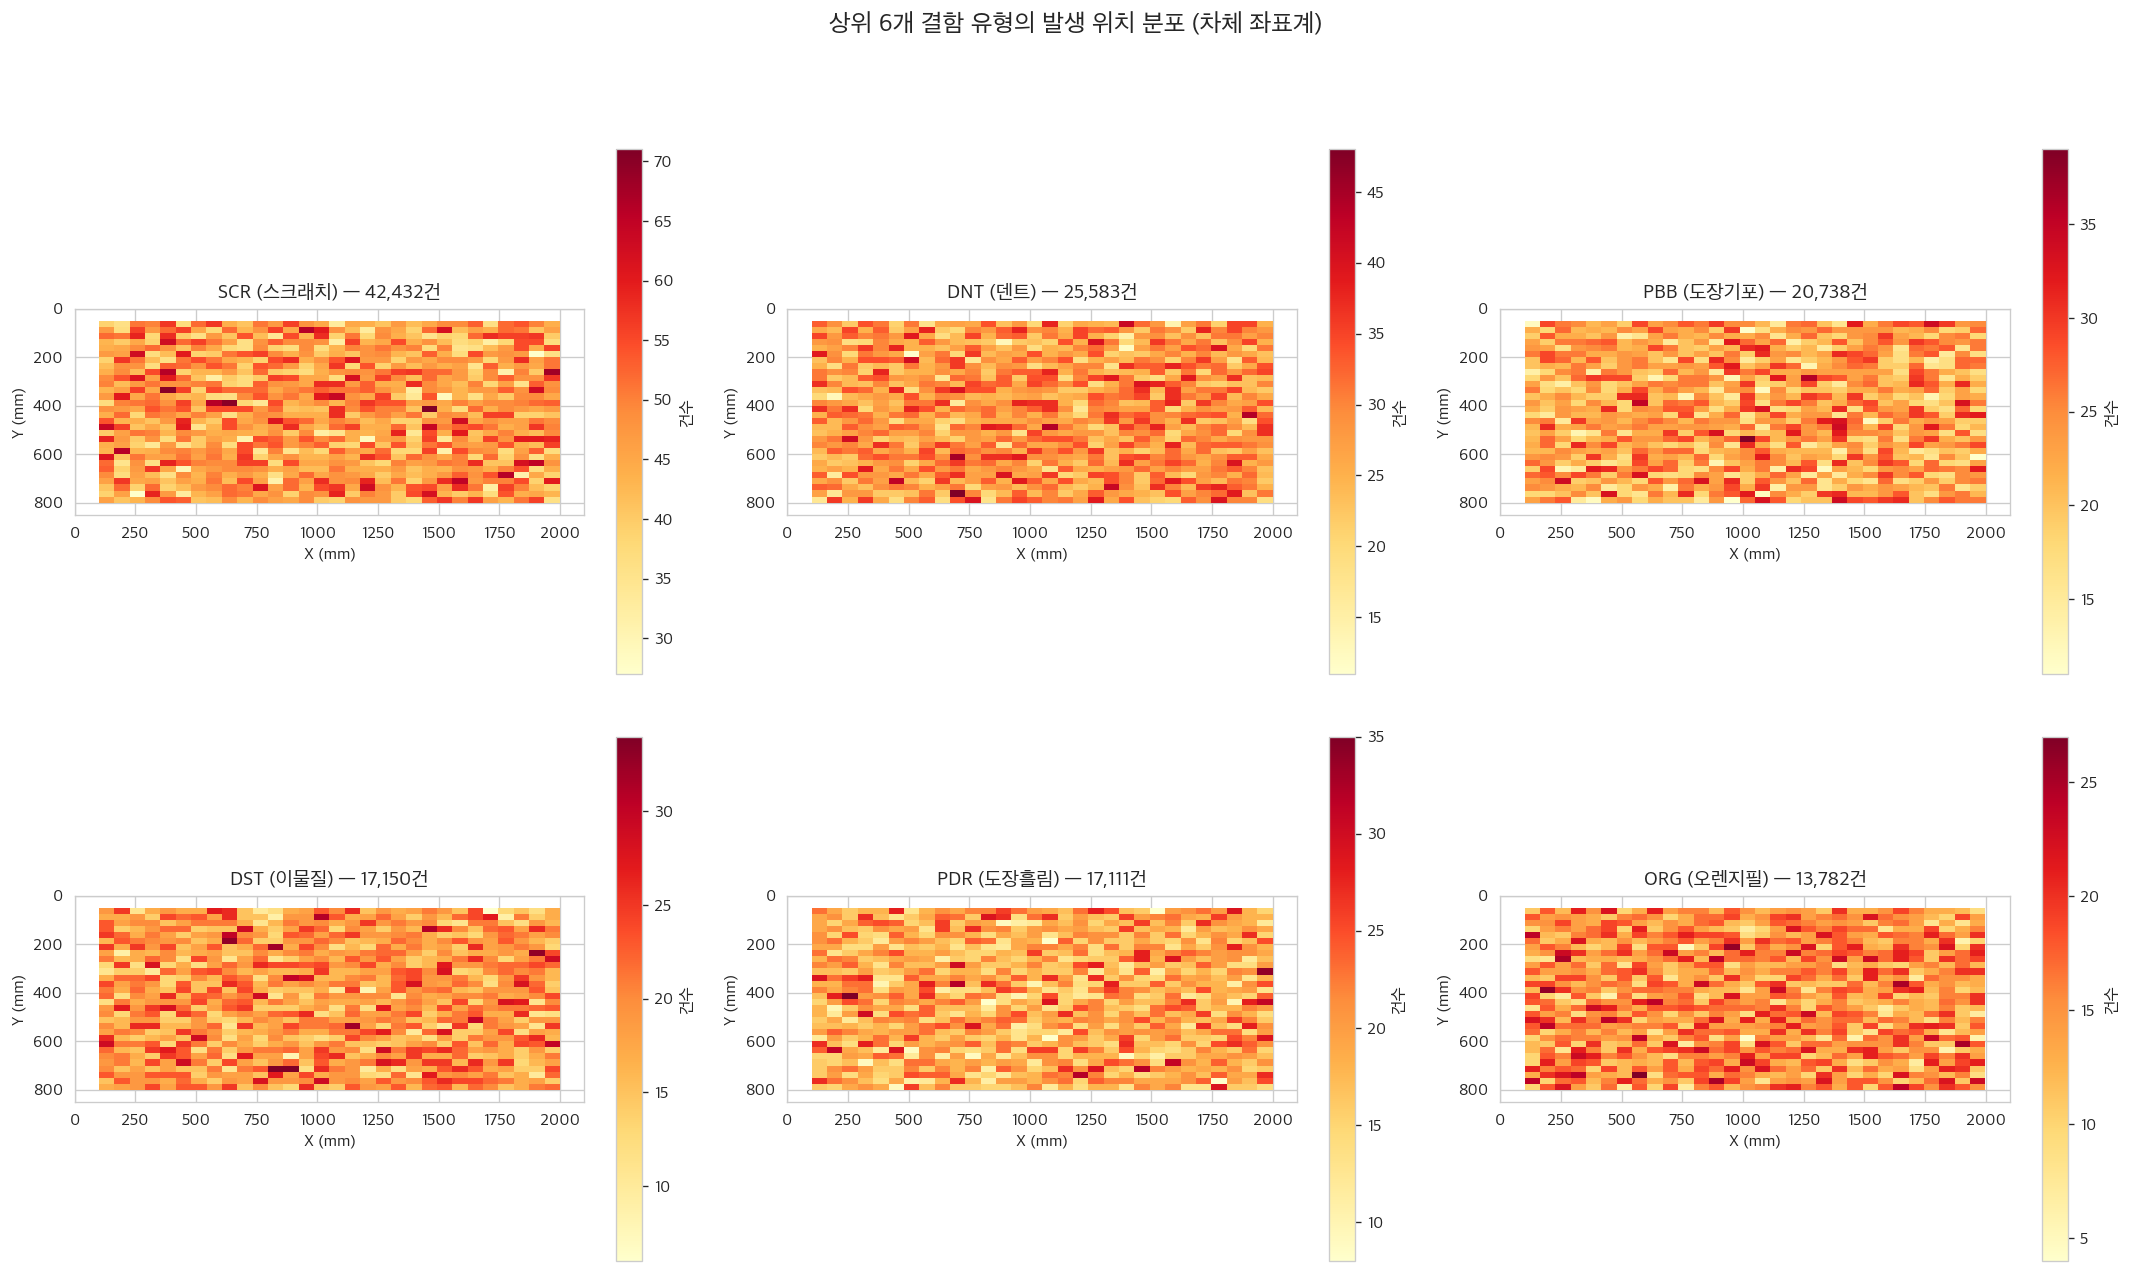

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# 상위 6개 결함 유형의 공간 분포
top6_defects = dd['defect_type_code'].value_counts().head(6).index.tolist()

for idx, defect_code in enumerate(top6_defects):
    ax = axes[idx // 3][idx % 3]
    subset = dd[dd['defect_type_code'] == defect_code]
    name = type_name_map[defect_code]

    # 2D 히스토그램 (히트맵)
    h = ax.hist2d(subset['x_position_mm'], subset['y_position_mm'],
                  bins=30, cmap='YlOrRd', cmin=1)
    plt.colorbar(h[3], ax=ax, label='건수', shrink=0.8)

    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')
    ax.set_title(f'{defect_code} ({name}) — {len(subset):,}건', fontsize=12, fontweight='bold')
    ax.set_xlim(0, 2100)
    ax.set_ylim(0, 850)
    ax.invert_yaxis()
    ax.set_aspect('equal')

plt.suptitle('상위 6개 결함 유형의 발생 위치 분포 (차체 좌표계)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 인사이트
- **결함 위치가 차체 좌표 전역에 균등 분포** — 특정 위치(예: 모서리, 접합부)에 집중되는 패턴이 보이지 않음
- 시뮬레이션 데이터 특성으로 x, y 좌표가 독립적 균일분포에서 생성된 것으로 추정
- 실제 데이터라면 **도어 엣지, 범퍼 곡면부, 루프 중앙** 등에 결함이 집중될 것으로 예상

---
## 12. 재작업 비용 분석 — 결함 유형별 경제적 임팩트

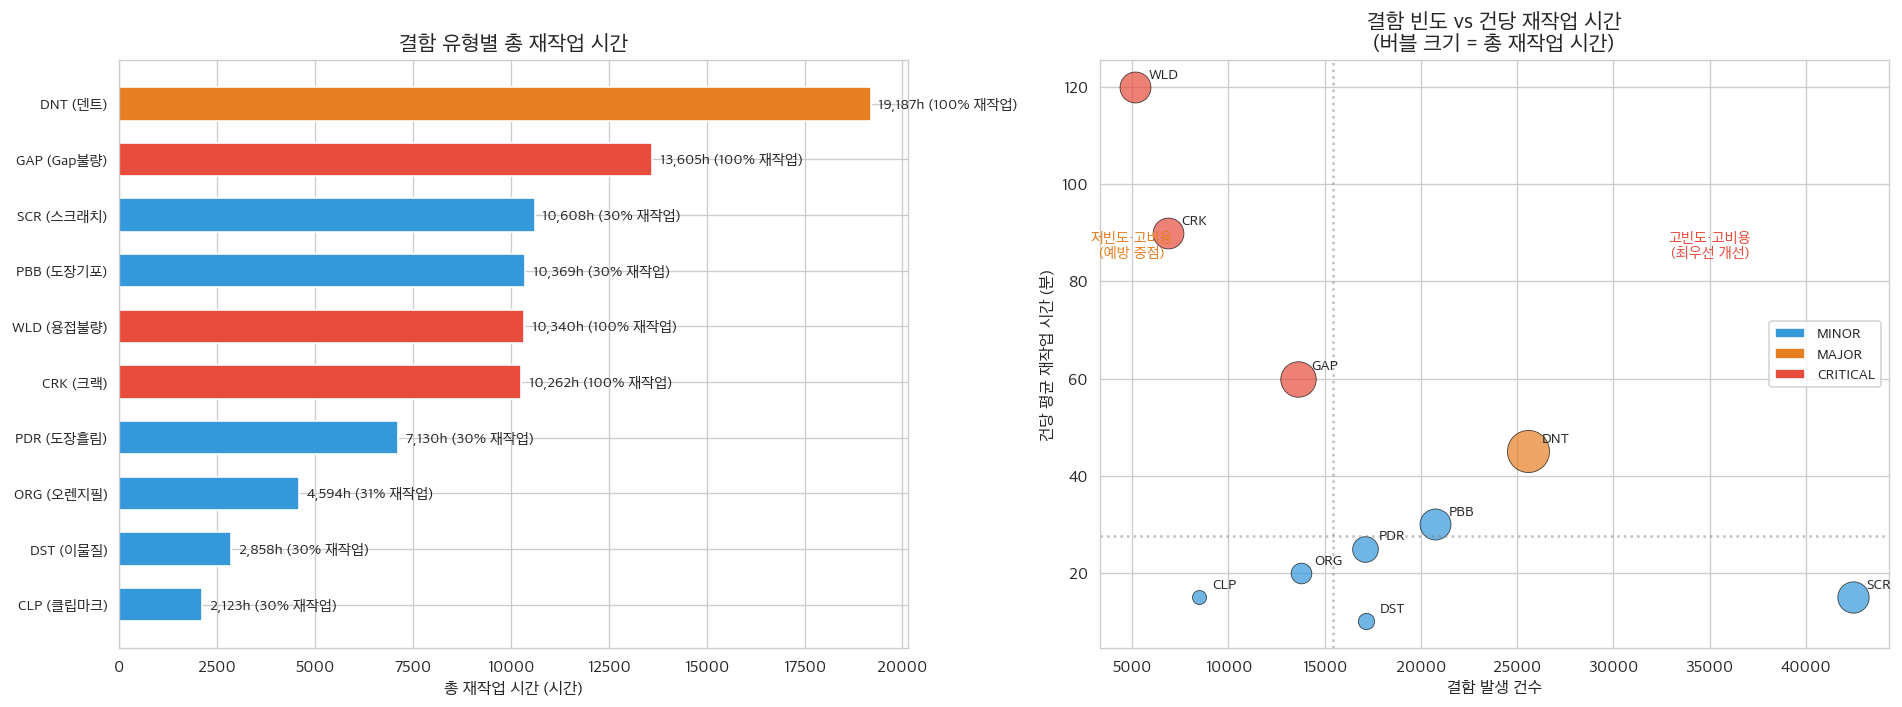

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 재작업 분석
rework_stats = dd.groupby('defect_type_code').agg(
    total_defects=('defect_id', 'count'),
    rework_y=('rework_required', lambda x: (x == 'Y').sum()),
    total_rework_hrs=('estimated_rework_min', lambda x: x.sum() / 60),
    avg_rework_min=('estimated_rework_min', 'mean')
).reset_index()
rework_stats['rework_rate'] = rework_stats['rework_y'] / rework_stats['total_defects'] * 100
rework_stats['defect_name'] = rework_stats['defect_type_code'].map(type_name_map)
rework_stats = rework_stats.sort_values('total_rework_hrs', ascending=True)

# 12-1. 총 재작업 시간 (수평 바)
colors_rw = []
for _, row in rework_stats.iterrows():
    sev = m_defect.set_index('defect_type_code').loc[row.defect_type_code, 'severity']
    colors_rw.append(sev_color_map[sev])

bars = axes[0].barh(range(len(rework_stats)), rework_stats['total_rework_hrs'],
                    color=colors_rw, edgecolor='white', height=0.6)
for i, (_, row) in enumerate(rework_stats.iterrows()):
    axes[0].text(row.total_rework_hrs + 200, i,
                 f"{row.total_rework_hrs:,.0f}h ({row.rework_rate:.0f}% 재작업)",
                 va='center', fontsize=9)
axes[0].set_yticks(range(len(rework_stats)))
axes[0].set_yticklabels([f"{r.defect_type_code} ({r.defect_name})" for _, r in rework_stats.iterrows()], fontsize=9)
axes[0].set_xlabel('총 재작업 시간 (시간)')
axes[0].set_title('결함 유형별 총 재작업 시간', fontsize=13, fontweight='bold')

# 12-2. 건당 재작업 시간 vs 발생 빈도 (버블 차트)
for _, row in rework_stats.iterrows():
    sev = m_defect.set_index('defect_type_code').loc[row.defect_type_code, 'severity']
    axes[1].scatter(row.total_defects, row.avg_rework_min,
                    s=row.total_rework_hrs / 30, alpha=0.7,
                    color=sev_color_map[sev], edgecolors='black', linewidth=0.5)
    axes[1].annotate(f"{row.defect_type_code}",
                     (row.total_defects, row.avg_rework_min),
                     textcoords="offset points", xytext=(8, 5), fontsize=9, fontweight='bold')

axes[1].set_xlabel('결함 발생 건수')
axes[1].set_ylabel('건당 평균 재작업 시간 (분)')
axes[1].set_title('결함 빈도 vs 건당 재작업 시간\n(버블 크기 = 총 재작업 시간)', fontsize=13, fontweight='bold')

# 사분면 기준선
axes[1].axhline(y=rework_stats['avg_rework_min'].median(), color='gray', linestyle=':', alpha=0.5)
axes[1].axvline(x=rework_stats['total_defects'].median(), color='gray', linestyle=':', alpha=0.5)
axes[1].text(35000, 85, '고빈도·고비용\n(최우선 개선)', fontsize=9, color='#e74c3c', ha='center', style='italic')
axes[1].text(5000, 85, '저빈도·고비용\n(예방 중점)', fontsize=9, color='#e67e22', ha='center', style='italic')

legend_sev = [Patch(facecolor=c, label=s) for s, c in sev_color_map.items()]
axes[1].legend(handles=legend_sev, fontsize=9, loc='center right')

plt.tight_layout()
plt.show()

### 인사이트
- **DNT(덴트)가 재작업 비용 1위** — 총 19,187시간. MAJOR 등급이라 100% 재작업 필수
- **WLD(용접불량)와 CRK(크랙)은 건수는 적지만 건당 비용이 극히 높음** (90~120분/건) — 예방에 집중해야 할 대상
- **SCR(스크래치)는 건수 1위지만 30%만 재작업** — 경미한 스크래치는 허용 기준 내로 판단되는 듯
- **버블차트 "고빈도·고비용" 사분면**: DNT가 유일하게 해당 → 가장 높은 개선 ROI
- **비즈니스 제안**: ① DNT 예방(차체 핸들링 개선), ② WLD/CRK 발생 시 즉시 라인 정지 프로토콜

---
## 13. 수치형 변수 상관관계 및 분포

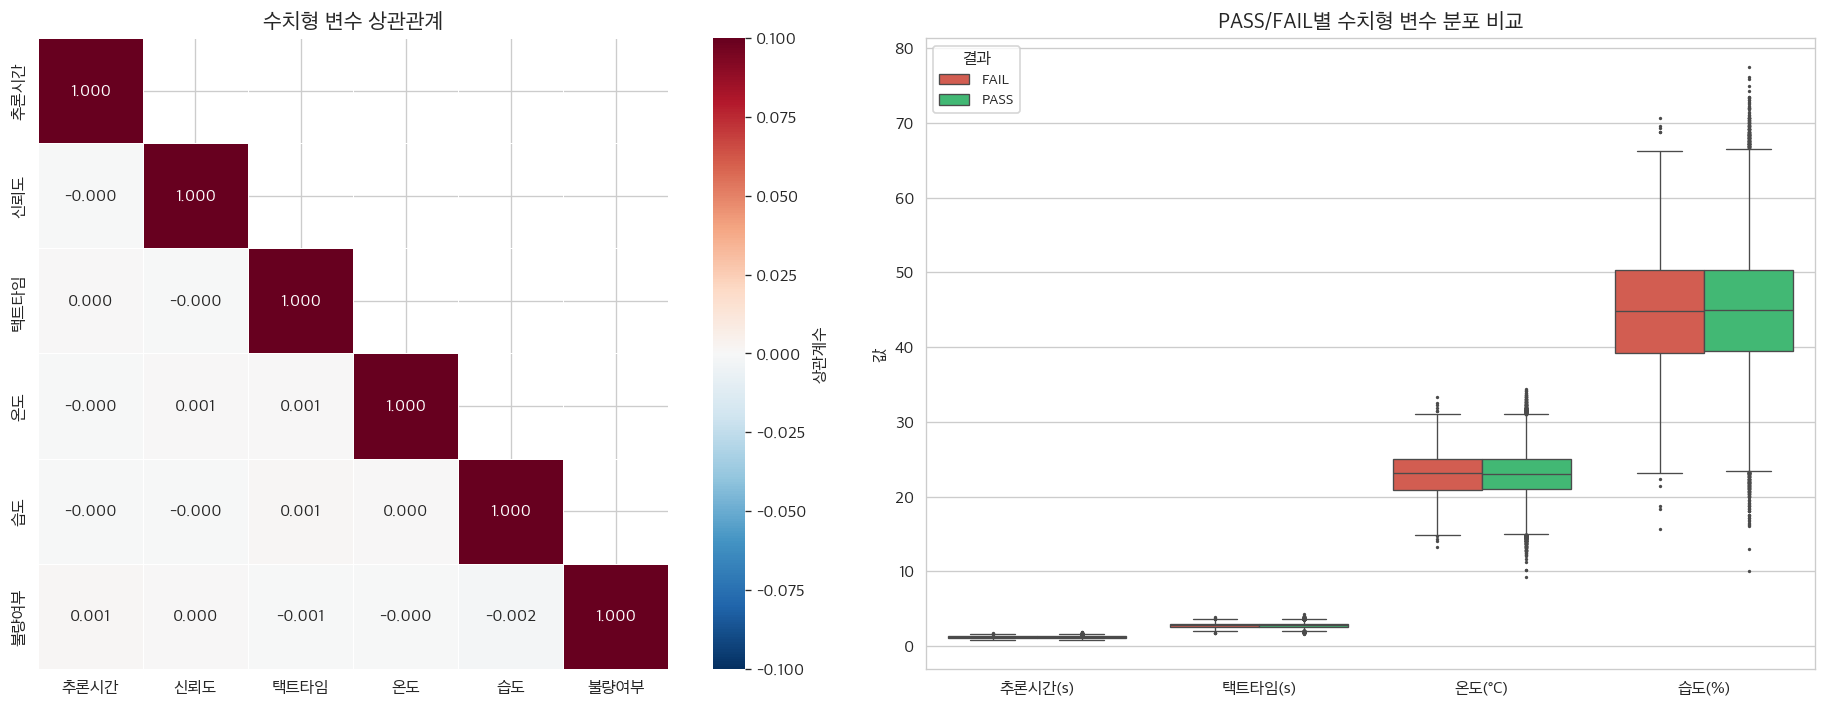

In [15]:
# 상관관계 히트맵 + 수치형 분포
num_cols = ['inference_time_sec', 'confidence_score', 'takt_time_sec', 'ambient_temp_c', 'humidity_pct', 'is_fail']
num_labels = ['추론시간', '신뢰도', '택트타임', '온도', '습도', '불량여부']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 13-1. 상관관계 히트맵
corr = im[num_cols].corr()
corr_display = corr.copy()
corr_display.index = num_labels
corr_display.columns = num_labels

mask_upper = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr_display, mask=mask_upper, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, ax=axes[0], linewidths=0.5, square=True,
            vmin=-0.1, vmax=0.1, cbar_kws={'label': '상관계수'})
axes[0].set_title('수치형 변수 상관관계', fontsize=13, fontweight='bold')

# 13-2. 주요 수치형 변수 boxplot (PASS vs FAIL)
plot_cols = ['inference_time_sec', 'takt_time_sec', 'ambient_temp_c', 'humidity_pct']
plot_labels = ['추론시간(s)', '택트타임(s)', '온도(°C)', '습도(%)']

# Normalize for comparison
im_sample = im.sample(50000, random_state=42)  # 성능 위해 샘플링
melted = pd.melt(im_sample, id_vars=['result'], value_vars=plot_cols,
                 var_name='variable', value_name='value')
label_map = dict(zip(plot_cols, plot_labels))
melted['variable'] = melted['variable'].map(label_map)

sns.boxplot(data=melted, x='variable', y='value', hue='result',
            palette={'PASS': '#2ecc71', 'FAIL': '#e74c3c'}, ax=axes[1],
            fliersize=1, linewidth=0.8)
axes[1].set_xlabel('')
axes[1].set_ylabel('값')
axes[1].set_title('PASS/FAIL별 수치형 변수 분포 비교', fontsize=13, fontweight='bold')
axes[1].legend(title='결과', fontsize=9)

plt.tight_layout()
plt.show()

### 인사이트
- **모든 수치형 변수와 불량 여부(is_fail) 간 상관계수 ≈ 0** — 선형 관계가 없음
- 수치형 변수 간에도 상관이 거의 없어 **독립적으로 생성된 시뮬레이션 데이터** 특성이 뚜렷
- PASS/FAIL 간 boxplot 분포도 거의 동일 — 이 데이터셋에서는 수치형 피처 단독으로는 불량 예측이 어려움
- **모델링 시사점**: 단순 수치형 피처보다는 **교대조(shift), 시간대(hour)** 같은 범주형/시간 피처가 더 유용할 것

---
## 14. 모델(차종)별 분석

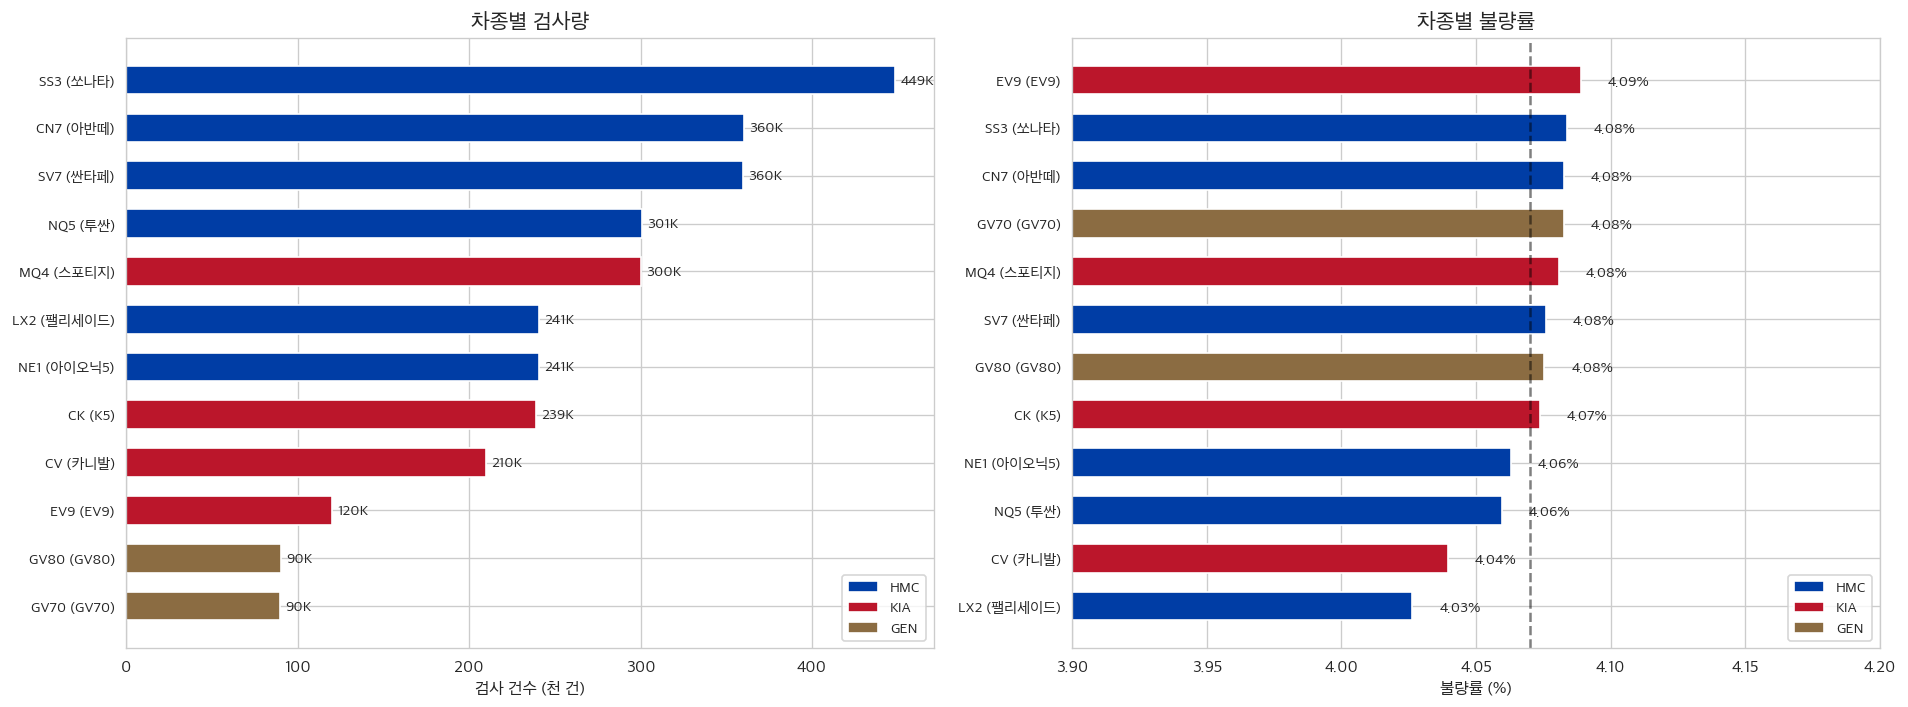

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 14-1. 차종별 검사량 + 불량률
model_stats = im.groupby('model_code').agg(
    total=('is_fail', 'count'), fails=('is_fail', 'sum')
)
model_stats['fail_rate'] = model_stats['fails'] / model_stats['total'] * 100
model_stats = model_stats.sort_values('total', ascending=True)
model_stats['model_name'] = model_stats.index.map(m_model.set_index('model_code')['model_name'])
model_stats['brand'] = model_stats.index.map(m_model.set_index('model_code')['brand'])

brand_colors = {'HMC': '#003DA5', 'KIA': '#BB162B', 'GEN': '#8B6C42'}
bar_colors_m = [brand_colors[b] for b in model_stats['brand']]

bars = axes[0].barh(range(len(model_stats)), model_stats['total'] / 1000,
                    color=bar_colors_m, edgecolor='white', height=0.6)
for i, (idx, row) in enumerate(model_stats.iterrows()):
    axes[0].text(row.total / 1000 + 3, i, f"{row.total/1000:.0f}K", va='center', fontsize=9)
axes[0].set_yticks(range(len(model_stats)))
axes[0].set_yticklabels([f"{idx} ({row.model_name})" for idx, row in model_stats.iterrows()], fontsize=9)
axes[0].set_xlabel('검사 건수 (천 건)')
axes[0].set_title('차종별 검사량', fontsize=13, fontweight='bold')
legend_brand = [Patch(facecolor=c, label=b) for b, c in brand_colors.items()]
axes[0].legend(handles=legend_brand, fontsize=9, loc='lower right')

# 14-2. 차종별 불량률 (색상으로 브랜드 구분)
model_fr = model_stats.sort_values('fail_rate', ascending=True)
bar_colors_fr = [brand_colors[b] for b in model_fr['brand']]
bars2 = axes[1].barh(range(len(model_fr)), model_fr['fail_rate'],
                     color=bar_colors_fr, edgecolor='white', height=0.6)
for i, (idx, row) in enumerate(model_fr.iterrows()):
    axes[1].text(row.fail_rate + 0.01, i, f"{row.fail_rate:.2f}%", va='center', fontsize=9, fontweight='bold')
axes[1].set_yticks(range(len(model_fr)))
axes[1].set_yticklabels([f"{idx} ({row.model_name})" for idx, row in model_fr.iterrows()], fontsize=9)
axes[1].set_xlabel('불량률 (%)')
axes[1].set_title('차종별 불량률', fontsize=13, fontweight='bold')
axes[1].axvline(x=4.07, color='black', linestyle='--', alpha=0.5)
axes[1].set_xlim(3.9, 4.2)
axes[1].legend(handles=legend_brand, fontsize=9, loc='lower right')

plt.tight_layout()
plt.show()

### 인사이트
- **차종별 불량률 차이가 극히 미미** (4.03~4.09%) — 브랜드(HMC/KIA/GEN) 간에도 유의미한 차이 없음
- **검사량은 차종별로 큰 차이** — SS3(쏘나타, 449K)이 최다, GV70/GV80(90K)이 최소. 양산 모델이 더 많은 검사를 받음
- 차종은 불량 예측 모델에서 유용한 피처가 아닐 가능성이 높음

---
## 15. 종합 요약 — 핵심 발견사항 및 제언

### A. 데이터 품질
| 항목 | 판정 |
|---|---|
| 결측치 | 전 테이블 0% — 완벽 |
| FK 정합성 | 100% 매칭 |
| 집계 일관성 | daily_summary ↔ inspection_master 완전 일치 |
| 시뮬레이션 특성 | 구역 균등분포, 수치형 변수 독립, confidence 무상관 등에서 인공 데이터 특성 확인 |

### B. 가장 중요한 3가지 발견

| # | 발견 | 임팩트 | 제안 |
|---|---|---|---|
| 1 | **C조(야간) 불량률 6.02%** — 평균 대비 48%↑ | 연간 약 4,000건 추가 불량 | 야간 품질 감독 강화, 교대 직후 모니터링 |
| 2 | **교대 시작 직후(6~7시, 21시) 불량 급증** | 설비 워밍업 + 인수인계 공백 | 교대 전 설비 예열, 교대 시 30분 집중 검사 |
| 3 | **저습도(< 25%) 환경에서 불량률 상승** | 건조 환경이 도장 품질에 악영향 | 도장 부스 습도 모니터링 알림 시스템 |

### C. 결함 관리 우선순위

| 우선순위 | 기준 | 대상 결함 |
|---|---|---|
| **1순위** | 재작업 비용 최대 | DNT(덴트) — 19,187시간, 100% 재작업 |
| **2순위** | 건당 비용 극대 | WLD(용접불량), CRK(크랙) — 90~120분/건 |
| **3순위** | 발생 빈도 최다 | SCR(스크래치) — 42,432건, 다중결함의 핵심 동반자 |

### D. 모델링 시사점
- **유효한 피처**: `shift` (교대조), `hour` (시간대), `humidity_pct` (습도, 특히 저습도 구간)
- **무효한 피처**: `confidence_score` (PASS/FAIL 무관), 수치형 변수 대부분 (상관 ≈ 0)
- **불균형 처리 필요**: FAIL 4.07% → SMOTE, class_weight 등 적용 필요
- 범주형 교차(shift × hour, shift × plant) 피처 엔지니어링 권장